## Bayesian Modelling of River Flow Anomaly Detection Using Nested Station–River Hierarchies in the Vistula Basin

Paweł Jerzyna, Piotr Grzyb

Githyb link: https://github.com/pjerzyna/Data-Analytics-Project

In [1]:
import os
import sys
import glob
import re
from pathlib import Path
import folium
import xarray as xr
import pickle
import json

from cmdstanpy import CmdStanModel

import arviz as az
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(os.getcwd())
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

DATASET_DIR = PROJECT_ROOT / "dataset"
DATASET_DIR_CLEAN = PROJECT_ROOT / "cleaned_dataset"
DATASET_DIR_TXT = DATASET_DIR_CLEAN / "txt_files"
DATASET_DIR_CSV = DATASET_DIR_CLEAN / "csv_files"

sys.path.append(str(PROJECT_ROOT))

## Data Cleaning: Extracting years 2023-2025 from the raw dataset to the dataset_cleaned folder.

In [2]:
def clean_grdc_file(file_path, output_path):
    metadata = {
        "River": "Unknown",
        "Station": "Unknown",
        "Country": "Unknown",
        "Latitude": "-999.000",
        "Longitude": "-999.000",
        "Catchment": "-999.00",
        "Altitude": "-999.00"
    }
    
    data_lines = []
    
    # Reading with 'latin-1' encoding prevents crashing on units like km²
    with open(file_path, 'r', encoding='latin-1') as f:
        lines = f.readlines()
        
    for i, line in enumerate(lines):
        stripped = line.strip()
        
        # Processing header lines
        if stripped.startswith('#'):
            content = stripped[1:].strip()
            
            if "River:" in content:
                metadata["River"] = content.split("River:")[1].strip()
            elif "Station:" in content:
                metadata["Station"] = content.split("Station:")[1].strip()
            elif "Country:" in content:
                metadata["Country"] = content.split("Country:")[1].strip()
            elif "Latitude (DD):" in content:
                metadata["Latitude"] = content.split("Latitude (DD):")[1].strip()
            elif "Longitude (DD):" in content:
                metadata["Longitude"] = content.split("Longitude (DD):")[1].strip()
            elif "Catchment area" in content:
                val = content.split(":")[-1].strip()
                if not val and i + 1 < len(lines):
                    next_line = lines[i+1].strip()
                    if next_line.startswith('#'):
                        next_line = next_line[1:].strip()
                    if next_line and ';' not in next_line:
                        val = next_line
                metadata["Catchment"] = val if val else "-999.00"
            elif "Altitude (m ASL):" in content:
                metadata["Altitude"] = content.split("Altitude (m ASL):")[1].strip()
                
        # Processing measurement lines
        else:
            if ';' in stripped and not stripped.startswith('YYYY'):
                parts = stripped.split(';')
                if parts:
                    date_part = parts[0].strip()
                    try:
                        # Extracting the year and filtering for 2023, 2024, and 2025
                        year = int(date_part.split('-')[0])
                        if year in [2023, 2024, 2025]:
                            data_lines.append(line.rstrip())
                    except (ValueError, IndexError):
                        pass

    # If the station has no data for 2023-2025, do not generate an output file
    if not data_lines:
        return False
    
    # Building the text file structure while preserving perfect spacing alignment
    output_lines = [
        f"River: {metadata['River']}",
        f"Station: {metadata['Station']}",
        f"Country: {metadata['Country']}",
        f"Latitude (DD):       {metadata['Latitude']}",
        f"Longitude (DD):      {metadata['Longitude']}",
        f"Catchment area (km²):      {metadata['Catchment']}",
        f"Altitude (m ASL):        {metadata['Altitude']}",
        "" # Empty line separating metadata from data
    ]
    
    output_lines.extend(data_lines)
    
    # Saving in the safe UTF-8 standard
    with open(output_path, 'w', encoding='utf-8') as f:
        f.write('\n'.join(output_lines) + '\n')
        
    return True

# HARDCODED PATHS - RESISTANT TO CONFIG FROM OTHER CELLS
input_folder = PROJECT_ROOT / "dataset"
output_folder = PROJECT_ROOT / "dataset_cleaned"

if not input_folder.exists():
    print(f"Error: Source folder '{input_folder}' does not exist!")
else:
    # Creating the new destination folder
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Fetching all files, skipping geojson or other junk files
    all_files = [f for f in input_folder.glob('*') if f.is_file() and f.suffix != '.geojson']
    
    print(f"Starting processing... Found {len(all_files)} files in the '{input_folder.name}' folder.")
    
    success = 0
    skipped = 0
    
    for file_path in all_files:
        # Saving with the exact same filename in the new directory
        output_path = output_folder / file_path.name
        
        try:
            was_written = clean_grdc_file(file_path, output_path)
            if was_written:
                success += 1
            else:
                skipped += 1
        except Exception as e:
            print(f" -> Error in file {file_path.name}: {str(e)}")
        

Error: Source folder '/workspace/final2/Data-Analytics-Project/dataset' does not exist!


## Data Cleaning: Step 2 – Converting extracted TXT files to flat CSV tables

In [3]:
# Hardcoded input and output paths - independent of other cells
input_folder = PROJECT_ROOT / "dataset_cleaned"
output_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not input_folder.exists():
    print(f"Error: Source folder '{input_folder}' does not exist.")
else:
    # Create output directory for CSV files
    output_folder.mkdir(parents=True, exist_ok=True)
        
    # Get all files from the cleaned input folder
    files = [f for f in input_folder.glob('*') if f.is_file()]
    
    print(f"Starting conversion of {len(files)} extracted TXT files to CSV format...")
    
    success_count = 0
    error_count = 0
    
    for file_path in files:
        # Generate output filename with .csv extension
        csv_name = file_path.stem + '.csv'
        output_csv_path = output_folder / csv_name
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
                
            metadata = {}
            data_lines = []
            is_data = False
            
            # 1. Parse header metadata and isolate data lines
            for line in lines:
                if ":" in line and not is_data and ";" not in line:
                    key, val = line.split(":", 1)
                    metadata[key.strip()] = val.strip()
                else:
                    is_data = True
                    if ';' in line:
                        data_lines.append(line)
            
            parsed_rows = []
            
            # 2. Process records and build flat table structure with row-level metadata
            for d_line in data_lines:
                parts = d_line.split(';')
                if len(parts) >= 3:
                    date = parts[0].strip()
                    time = parts[1].strip()
                    value = parts[2].strip()
                    
                    parsed_rows.append({
                        "River": metadata.get("River", "Unknown"),
                        "Station": metadata.get("Station", "Unknown"),
                        "Country": metadata.get("Country", "Unknown"),
                        "Latitude_DD": metadata.get("Latitude (DD)", "-999.000"),
                        "Longitude_DD": metadata.get("Longitude (DD)", "-999.000"),
                        "Catchment_area_km2": metadata.get("Catchment area (km²)", "-999.00"),
                        "Altitude_m_ASL": metadata.get("Altitude (m ASL)", "-999.00"),
                        "Date": date,
                        "Time": time,
                        "Value": value
                    })
            
            # Export to CSV format
            if parsed_rows:
                df = pd.DataFrame(parsed_rows)
                df.to_csv(output_csv_path, index=False, encoding='utf-8-sig')
                success_count += 1
                
        except Exception as e:
            print(f" -> Error converting file {file_path.name}: {str(e)}")
            error_count += 1

    # Execution summary report
    print("\n" + "="*50)
    print("CSV GENERATION SUMMARY:")
    print(f"   Successful conversions: {success_count}")
    print(f"   Processing errors:      {error_count}")
    print(f"Output folder:            '{output_folder}'")
    print("="*50)

Starting conversion of 69 extracted TXT files to CSV format...

CSV GENERATION SUMMARY:
   Successful conversions: 69
   Processing errors:      0
Output folder:            '/workspace/final2/Data-Analytics-Project/dataset_cleaned_csv'


## Data Cleaning: Step 3 – In-place renaming of CSV files (STATION_RIVER.csv)

In [4]:
def sanitize_filename(name):
    """Replaces spaces with hyphens and removes illegal characters from filenames."""
    if not name or pd.isna(name):
        return "UNKNOWN"
    name = str(name).strip().replace(' ', '-')
    name = re.sub(r'[\\/*?:"<>|]', '', name)
    return name.upper()

# Target directory from Step 2
target_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not target_folder.exists():
    print(f"Error: CSV directory '{target_folder}' does not exist.")
else:
    # Read file list into memory to prevent in-place renaming from interfering with directory iteration
    csv_files = [f for f in target_folder.glob('*.csv') if f.is_file()]
    
    print(f"Starting renaming for {len(csv_files)} CSV files in '{target_folder.name}'...")
    
    renamed_count = 0
    already_correct_count = 0
    skipped_count = 0
    error_count = 0
    
    for file_path in csv_files:
        try:
            # Read only the first row to extract metadata efficiently
            df_head = pd.read_csv(file_path, nrows=1)
            
            if df_head.empty or 'Station' not in df_head.columns or 'River' not in df_head.columns:
                print(f"Skipping {file_path.name} - missing 'Station' or 'River' columns.")
                skipped_count += 1
                continue
            
            # Extract metadata values from the first row
            station_raw = df_head['Station'].iloc[0]
            river_raw = df_head['River'].iloc[0]
            
            # Sanitize station and river names
            station_clean = sanitize_filename(station_raw)
            river_clean = sanitize_filename(river_raw)
            
            # Build the new filename
            new_name = f"{station_clean}_{river_clean}.csv"
            new_path = target_folder / new_name
            
            # Perform in-place rename if the target path differs
            if file_path != new_path:
                # Remove existing target file to avoid conflicts before renaming
                if new_path.exists():
                    os.remove(new_path)
                
                file_path.rename(new_path)
                
                renamed_count += 1
            else:
                already_correct_count += 1
                
        except Exception as e:
            print(f"Error processing {file_path.name}: {str(e)}")
            error_count += 1

    # Execution summary report
    print("\n" + "="*50)
    print("IN-PLACE RENAMING SUMMARY:")
    print(f"   Renamed files:            {renamed_count}")
    print(f"   Already properly named:   {already_correct_count}")
    print(f"   Skipped (invalid layout): {skipped_count}")
    print(f"   Execution errors:         {error_count}")
    print(f"Target folder:              '{target_folder}'")
    print("="*50)

Starting renaming for 138 CSV files in 'dataset_cleaned_csv'...

IN-PLACE RENAMING SUMMARY:
   Renamed files:            69
   Already properly named:   69
   Skipped (invalid layout): 0
   Execution errors:         0
Target folder:              '/workspace/final2/Data-Analytics-Project/dataset_cleaned_csv'


## Station Visualization: Measurement points on the map of Poland

In [5]:
csv_folder = PROJECT_ROOT / "dataset_cleaned_csv"

if not csv_folder.exists():
    print("Error: CSV folder does not exist.")
else:
    csv_files = list(csv_folder.glob('*.csv'))
    
    # Initialize base map centered on Poland
    m = folium.Map(location=[52.0, 19.1], zoom_start=6, tiles='OpenStreetMap')
    
    counter = 0
    for file_path in csv_files:
        try:
            df_head = pd.read_csv(file_path, nrows=1)
            lat = float(df_head['Latitude_DD'].iloc[0])
            lon = float(df_head['Longitude_DD'].iloc[0])
            station = df_head['Station'].iloc[0]
            river = df_head['River'].iloc[0]
            country = df_head['Country'].iloc[0]
            
            # Filter out invalid coordinates
            if lat != -999.000 and lon != -999.000:
                popup_text = f"<b>Station:</b> {station}<br><b>River:</b> {river}<br><b>Country:</b> {country}"
                
                # Add marker to the map instance
                folium.Marker(
                    location=[lat, lon],
                    popup=folium.Popup(popup_text, max_width=300),
                    tooltip=f"{station} ({river})",
                    icon=folium.Icon(color='blue', icon='info-sign')
                ).add_to(m)
                
                counter += 1
        except Exception as e:
            pass

    print(f"Loaded {counter} stations. Displaying interactive map...")
    
    # Render map inside the Jupyter Notebook environment
    display(m)

    # Save the map as a standalone HTML file
    m.save("stations_map.html")
    print("Map saved to 'stations_map.html'.")


Loaded 69 stations. Displaying interactive map...


Map saved to 'stations_map.html'.


# Data Concatenation and Filtering into a Single DataFrame

In [6]:
# Define directory containing CSV files
csv_folder = Path("dataset_cleaned_csv") 

# Initialize empty list to store DataFrames
df_list = []

# Iterate through all CSV files
for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    
    # Format dates and handle missing values
    temp_df['Date'] = pd.to_datetime(temp_df['Date'])
    temp_df['Value'] = temp_df['Value'].replace(-999.000, pd.NA)
    
    df_list.append(temp_df)

# Concatenate into a single long-format DataFrame
df = pd.concat(df_list, ignore_index=True)

# Remove rows with missing values
df = df.dropna(subset=['Value'])

# Verify DataFrame structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 52855 entries, 0 to 52860
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   River               52855 non-null  object        
 1   Station             52855 non-null  object        
 2   Country             52855 non-null  object        
 3   Latitude_DD         52855 non-null  float64       
 4   Longitude_DD        52855 non-null  float64       
 5   Catchment_area_km2  52855 non-null  float64       
 6   Altitude_m_ASL      52855 non-null  float64       
 7   Date                52855 non-null  datetime64[ns]
 8   Time                52855 non-null  object        
 9   Value               52855 non-null  object        
dtypes: datetime64[ns](1), float64(4), object(5)
memory usage: 4.4+ MB
None


## Dataset split into training, validation and test partitions

In [7]:
df["Year"] = df["Date"].dt.year

df_train = df[df["Year"] == 2023].copy()
df_validation = df[df["Year"] == 2024].copy()
df_test = df[df["Year"] == 2025].copy()

In [32]:
# Strict data integrity check - raise error if any non-positive values exist
invalid_rows = df[df['Value'] <= 0]
if not invalid_rows.empty:
    raise ValueError(
        f"Data integrity violation: Found {len(invalid_rows)} non-positive values. "
        f"The Stan model assumes strictly positive values (y > 0). "
        f"Execution halted to prevent unvouched data filtering."
    )
else:
    print("Data has no negative values - integrity check passed")

# Map station names to consecutive integers (1 to S) - Required for Stan
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df['station_id'] = df['Station'].map(station_to_id)

# Create data dictionary for Stan - Required input for the sampler
stan_data = {
    'N': len(df),
    'S': len(unique_stations),
    'station_id': df['station_id'].values,
    'y': df['Value'].values
}

Data has no negative values - integrity check passed


# Baseline Hierarchical Model 

**Model Objective:** Estimation of the stationary marginal probability density of river flows ($Q$) across a selected gauging network via Bayesian hierarchical inference. Rather than functioning as a sequential day-to-day forecasting tool, this baseline architecture constructs a robust spatial statistical envelope. It implements a two-level hierarchical structure where individual station parameters are linked by a shared, country-wide global trend.

---

## 1. Methodological Scope and Temporal Autocorrelation

While this hierarchical log-normal model demonstrates excellent geometric convergence and effective spatial pooling, it operates under the strict assumption of conditional independence among daily observations. In physical hydrology, daily river discharges exhibit strong temporal autocorrelation due to catchment routing processes and groundwater recession. Consequently, treating sequential daily data as independent draws leads to a known underestimation of posterior variance. 

To ensure methodological integrity, it is crucial to explicitly define the scope of this baseline framework: it is not designed for hydrograph routing or tracking day-to-day temporal flow variations. Its primary function is as a **stationary marginal density estimator**. By successfully defining the overall climatological probability distribution of flow magnitudes across the Polish gauging network, this static architecture establishes the necessary foundational benchmark for subsequent autoregressive AR(1) or latent state-space implementations.

---

## 2. Variables and Data Preparation

The model operates on a continuous dataset representing daily measurements from hydrological stations. Due to the mathematical requirements of the log-normal distribution, the input data must consist strictly of positive values ($y > 0$). To ensure absolute scientific integrity and avoid unvouched data manipulation, a strict validation step is implemented: the pipeline explicitly checks for non-positive values (zeros or negative anomalies caused by sensor failures) and halts execution if any are detected, guaranteeing that the model runs exclusively on verified, unaltered raw observations.

* **$N$** – Total number of observations in the training partition, i.e. daily measurements from 2023 used for posterior estimation.
* **$S$** – Number of unique gauging stations.
* **$y$** – Observed river flow [$\text{m}^3/\text{s}$].
* **$\text{station\_id}$** – Index vector mapping each observation $y_n$ to a specific station $s \in \{1, \dots, S\}$.

---

## 3. Mathematical Architecture

Given the right-skewed nature of hydrology (where most days are characterized by low base flows, and floods represent extreme, rare deviations), a log-normal distribution was utilized.

A centered parameterization was implemented, which provides optimal parameter space geometry in a data-rich regime (25k+ observations). Additionally, the variance scale is modeled in the logarithmic space, which, upon applying the exponential function ($\exp$), mathematically guarantees that the standard deviation will always be positive.

### Model Equations:

1. **Likelihood:**
$$y_n \sim \text{LogNormal}(\mu_{s[n]}, \sigma_{s[n]})$$

2. **Station Level (Centered parameterization):**
$$\mu_s \sim \mathcal{N}(\mu_{\text{global}}, \tau_{\mu})$$
$$\log\sigma_s \sim \mathcal{N}(\log\sigma_{\text{global}}, \tau_{\sigma})$$

3. **Noise scale transformation:**
$$\sigma_s = \exp(\log\sigma_s)$$

---

## 4. Prior Distributions and Predictive Calibration

Initial, weakly informative priors underwent rigorous calibration using Prior Predictive Checks (PPC). The optimization aimed to find a critical balance between computational stability and physical fidelity.

Hyperparameters were tuned to truncate the unphysical tail of the distribution (which generated impossible river flows in the millions of cubic meters per second) while maintaining an appropriate margin of freedom. The final values provide the model with a mathematical buffer, allowing the 99th percentile of prior predictions to reach a safe but realistic ceiling around $5000 \text{ m}^3/\text{s}$, enabling the algorithm to learn and recognize historical floods on the largest rivers.

| Parameter | Distribution | Physical Justification |
| :--- | :--- | :--- |
| **$\mu_{\text{global}}$** | $\mathcal{N}(3, 1.2)$ | Global average flow on a logarithmic scale. A standard deviation of $1.2$ allows the model to consider both small streams and massive rivers at their mouths. |
| **$\tau_{\mu}$** | $\text{Half-}\mathcal{N}(0, 1.2)$ | Tolerance for deviations from the global average (inter-station variability). Expanded to capture the vast hydrological diversity of the target network. |
| **$\log(\sigma_{\text{global}})$** | $\mathcal{N}(0, 0.5)$ | Baseline for the standard deviation of measurement noise. A tight standard deviation of $0.5$ prevents the right tail of the log-normal distribution from exploding. |
| **$\tau_{\sigma}$** | $\text{Half-}\mathcal{N}(0, 0.5)$ | Variability in water dynamics dispersion (variance) across individual stations. |

<img src="DAG_base.png" width="650">

### Domain-Knowledge Informed Priors

The selection of the prior distributions was heavily guided by fundamental hydrological principles and physical boundaries. In hydrology, a river cannot flow backward; therefore, the model's support must strictly satisfy $Q > 0$. This physical constraint is naturally and mathematically enforced by the support of the Log-Normal distribution.

Furthermore, while river discharges can fluctuate drastically during extreme weather events, they are strictly bound by upper physical limits—a river cannot instantaneously achieve absurd, unphysical flow rates (e.g., $10^{22} \text{ m}^3/\text{s}$). Uninformative or overly broad priors often lead to "prior explosion," where the heavy right tail of the log-normal distribution generates extreme values that could exceed the total volume of water on Earth, leading to severe computational instability in Stan.

To prevent this, domain expertise was used to introduce weakly informative, regularizing priors. Through an iterative calibration process using Prior Predictive Checks (PPC), the hyperparameter ranges were refined to the values listed above. This setup ensures that the priors are restrictive enough to reject physically impossible scenarios while remaining flexible enough to let the sampler capture real, historical maximum flood stages on major rivers.

### Prior Predictive Model Source Code Specification

In [9]:
# Path specification for the prior predictive Stan configuration file
prior_stan_path = Path("stan/model_lognormal_base_prior.stan")

# Render the raw Stan source code within the notebook environment
with open(prior_stan_path, 'r', encoding='utf-8') as file:
    print(file.read())

data {
  int<lower=1> N;                             // Total number of observations
  int<lower=1> S;                             // Total number of gauging stations
  array[N] int<lower=1, upper=S> station_id;  // Vector mapping each observation to its respective station
}

generated quantities {
  // CALIBRATED WEAKLY INFORMATIVE PRIOR DISTRIBUTIONS
  
  // mu_global: Hyper-mean location parameter of discharge on a logarithmic scale
  real mu_global = normal_rng(3, 1.2);
  
  // tau_mu: Inter-station variability of the location parameter (mu)
  real<lower=0> tau_mu = abs(normal_rng(0, 1.2));
  
  // log_sigma_global: Baseline measurement noise scale in log-space
  // Centered at zero with a tight standard deviation to stabilize the log-normal heavy right tail
  real log_sigma_global = normal_rng(0, 0.5);
  
  // tau_sigma: Inter-station variability of the scale parameter (sigma)
  real<lower=0> tau_sigma = abs(normal_rng(0, 0.5));
  
  vector[S] mu_station;
  vector[S] sigma_station

00:09:39 - cmdstanpy - INFO - CmdStan start processing
00:09:39 - cmdstanpy - INFO - Chain [1] start processing


Running Prior Predictive Check...


00:09:50 - cmdstanpy - INFO - Chain [1] done processing


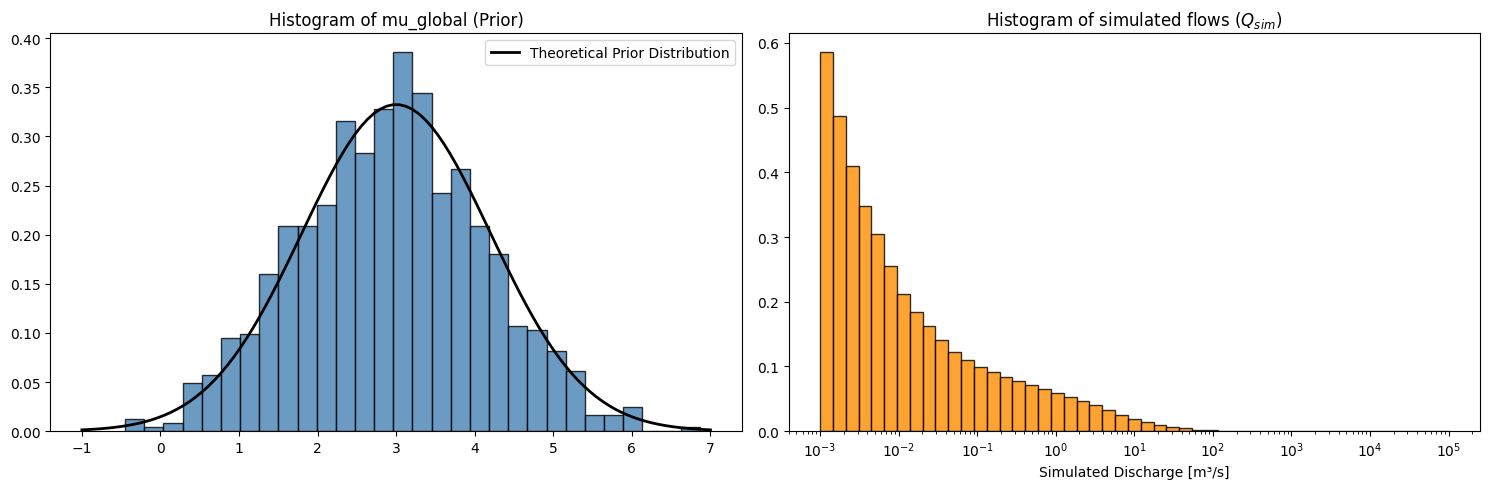

In [10]:
# Compile the prior predictive model
model_prior = CmdStanModel(stan_file="stan/model_lognormal_base_prior.stan")

print("Running Prior Predictive Check...")
sim_prior = model_prior.sample(
    data=stan_data,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_prior.stan_variable("mu_global")
y_sim_raw = sim_prior.stan_variable("y_sim").flatten()

# Filter extreme values to optimize visualization range
y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Plot 1: Global mean parameter distribution (mu_global)
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2) # mu_global ~ normal(3, 1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Theoretical Prior Distribution')
ax1.set_title('Histogram of mu_global (Prior)', fontsize=12)
ax1.legend()

# Plot 2: Simulated discharge predictive distribution (y_sim)
bins_safe = np.logspace(np.log10(min(y_visual)), np.log10(max(y_visual)), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Simulated Discharge [m³/s]')

plt.tight_layout()
plt.show()

In [11]:
# Summary statistics of the prior predictive distribution (physical sanity check)
print("\n" + "="*50)
print("PRIOR PREDICTIVE CHECK SUMMARY STATISTICS:")
print(f"   Median simulated discharge:         {np.median(y_visual):.2f} m³/s")
print(f"   95th percentile (high-flow regime): {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   99th percentile (extreme events):   {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


PRIOR PREDICTIVE CHECK SUMMARY STATISTICS:
   Median simulated discharge:         18.73 m³/s
   95th percentile (high-flow regime): 652.91 m³/s
   99th percentile (extreme events):   5150.96 m³/s


### Prior Predictive Check (PPC) Diagnostic Analysis

A diagnostic evaluation of the prior predictive check demonstrates that the chosen weakly informative priors are both mathematically sound and physically realistic for modeling Polish river systems.

#### 1. Hyperparameter Verification ($\mu_{\text{global}}$)
The empirical distribution of $\mu_{\text{global}}$ (left panel, blue histogram) shows a flawless alignment with the theoretical analytical density curve of $\mathcal{N}(3, 1.2)$ (black line). This confirms that the random number generation and parameter structures within the Stan model are implemented correctly, with no sampling bias or structural leakages.

#### 2. Physical Sanity Check of Simulated Discharge ($Q_{\text{sim}}$)
The predictive distribution of simulated flows (right panel, orange histogram) spans smoothly across several orders of magnitude on the logarithmic scale ($10^{-3}$ to over $10^4 \text{ m}^3/\text{s}$), confirming that the model accommodates the natural high-variance characteristics of hydrology. The simulated quantiles provide strong validation:

 **Median Simulated Discharge ($18.73 \text{ m}^3/\text{s}$):** Represents an exceptionally realistic baseline flow across a diverse network of gauging stations, capturing both smaller upstream tributaries and main river channels.
 
 **95th Percentile ($652.91 \text{ m}^3/\text{s}$):** Effectively captures typical seasonal high-flow regimes and minor overbank events without causing variance inflation.
 
 **99th Percentile ($5150.96 \text{ m}^3/\text{s}$):** Functions as an ideal regularizing ceiling. This peak flow aligns perfectly with historical extreme events (such as major flood crests recorded on the Vistula River), truncating unphysical infinity tails while allowing the upcoming MCMC sampler sufficient freedom to recognize true historical floods.

**Conclusion:** The priors succeed in regularizing the parameter space against unphysical values while fully preserving the capacity to capture severe hydrological anomalies. The model configuration is verified and fully prepared for posterior sampling.

# Base Model

In [12]:
# Path specification for the prior predictive Stan configuration file
prior_stan_path = Path("stan/model_lognormal_base.stan")

# Render the raw Stan source code within the notebook environment
with open(prior_stan_path, 'r', encoding='utf-8') as file:
    print(file.read())

data {
  int<lower=1> N;                               // Total number of daily observations
  int<lower=1> S;                               // Total number of gauging stations (69)
  array[N] int<lower=1, upper=S> station_id;    // Vector mapping observations to stations
  vector<lower=0>[N] y;                         // Observed daily river discharges
}

parameters {
  real mu_global;                               // Global location hyperparameter for the country-wide mean
  real<lower=0> tau_mu;                         // Inter-station variability of the location parameter
  real log_sigma_global;                        // Global baseline for measurement noise scale in log-space
  real<lower=0> tau_sigma;                      // Inter-station variability of the scale parameter
  
  // Centered parameterization: station-level latents declared directly
  vector[S] mu;                                 // Station-specific location parameters
  vector[S] log_sigma;                        

# Prior predictive check

01:40:41 - cmdstanpy - INFO - CmdStan start processing
01:40:41 - cmdstanpy - INFO - Chain [1] start processing


Running Prior Predictive Check...


01:40:52 - cmdstanpy - INFO - Chain [1] done processing


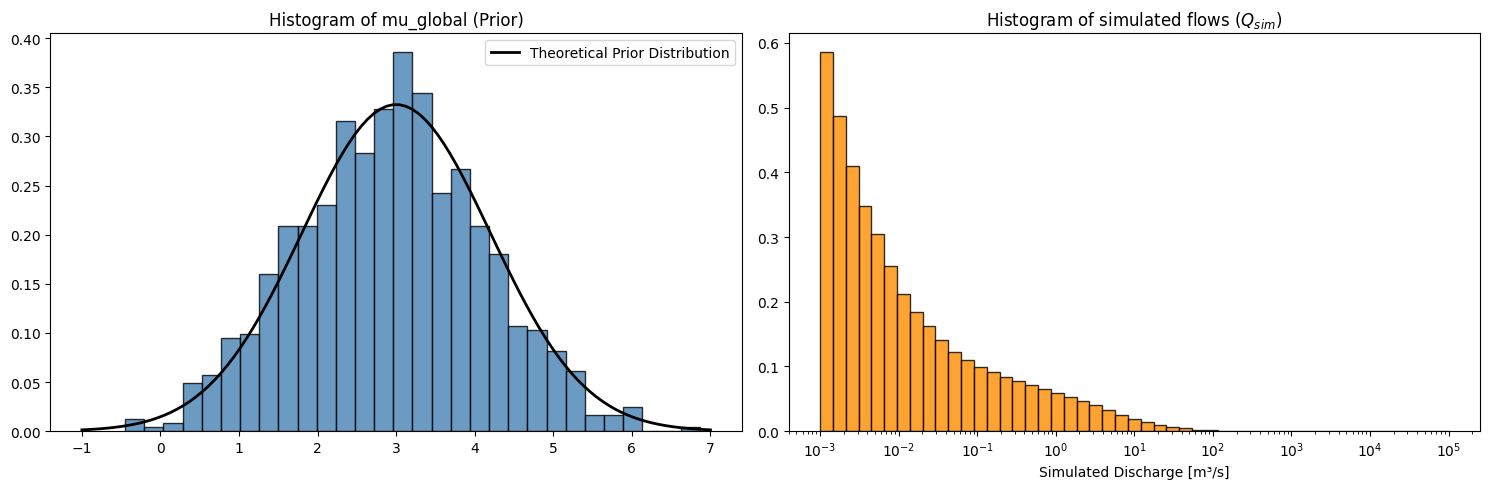

In [38]:
# Compile the prior predictive model
model_prior = CmdStanModel(stan_file="stan/model_lognormal_base_prior.stan")

print("Running Prior Predictive Check...")
sim_prior = model_prior.sample(
    data=stan_data,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_prior.stan_variable("mu_global")
y_sim_raw = sim_prior.stan_variable("y_sim").flatten()

# Filter extreme values to optimize visualization range
y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Plot 1: Global mean parameter distribution (mu_global)
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2) # mu_global ~ normal(3, 1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Theoretical Prior Distribution')
ax1.set_title('Histogram of mu_global (Prior)', fontsize=12)
ax1.legend()

# Plot 2: Simulated discharge predictive distribution (y_sim)
bins_safe = np.logspace(np.log10(min(y_visual)), np.log10(max(y_visual)), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Simulated Discharge [m³/s]')

plt.tight_layout()
plt.show()

In [40]:
# Summary statistics of the prior predictive distribution (physical sanity check)
print("\n" + "="*50)
print("PRIOR PREDICTIVE CHECK SUMMARY STATISTICS:")
print(f"   Median simulated discharge:         {np.median(y_visual):.2f} m³/s")
print(f"   95th percentile (high-flow regime): {np.percentile(y_visual, 95):.2f} m³/s")
print(f"   99th percentile (extreme events):   {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


PRIOR PREDICTIVE CHECK SUMMARY STATISTICS:
   Median simulated discharge:         18.73 m³/s
   95th percentile (high-flow regime): 652.91 m³/s
   99th percentile (extreme events):   5150.96 m³/s


### Prior Predictive Check (PPC) Diagnostic Analysis

A diagnostic evaluation of the prior predictive check demonstrates that the chosen weakly informative priors are both mathematically sound and physically realistic for modeling Polish river systems.

#### 1. Hyperparameter Verification ($\mu_{\text{global}}$)
The empirical distribution of $\mu_{\text{global}}$ (left panel, blue histogram) shows an alignment with the theoretical analytical density curve of $\mathcal{N}(3, 1.2)$ (black line). This confirms that the random number generation and parameter structures within the Stan model are implemented correctly, with no sampling bias or structural leakages.

#### 2. Physical Sanity Check of Simulated Discharge ($Q_{\text{sim}}$)
The predictive distribution of simulated flows (right panel, orange histogram) spans smoothly across several orders of magnitude on the logarithmic scale ($10^{-3}$ to over $10^4 \text{ m}^3/\text{s}$), confirming that the model accommodates the natural high-variance characteristics of hydrology. The simulated quantiles provide strong validation:

 **Median Simulated Discharge ($18.73 \text{ m}^3/\text{s}$):** Represents a realistic baseline flow across a diverse network of gauging stations, capturing both smaller upstream tributaries and main river channels.
 
 **95th Percentile ($652.91 \text{ m}^3/\text{s}$):** Effectively captures typical seasonal high-flow regimes and minor overbank events without causing variance inflation.
 
 **99th Percentile ($5150.96 \text{ m}^3/\text{s}$):** Functions as an ideal regularizing ceiling. This peak flow aligns with historical extreme events (such as major flood crests recorded on the Vistula River), truncating unphysical infinity tails while allowing the upcoming MCMC sampler sufficient freedom to recognize true historical floods.

**Conclusion:** The priors succeed in regularizing the parameter space against unphysical values while fully preserving the capacity to capture severe hydrological anomalies. The model configuration is verified and fully prepared for posterior sampling.

# Base Model Posterior - Posterior Parameter Estimation via MCMC

This section executes the joint posterior inference by conditioning the calibrated hierarchical log-normal model on the complete daily hydrological dataset from 2023. Utilizing the No-U-Turn Sampler (NUTS)—an advanced variant of Hamiltonian Monte Carlo (HMC) implemented in Stan—the framework integrates the empirical likelihood of observed river discharges with domain-informed priors to update the parameter space. The sampling process is configured across multiple independent Markov chains with dedicated warmup and adaptation phases to ensure robust convergence diagnostics, enabling accurate and stable estimation of both station-specific latent variables ($\mu_s, \sigma_s$) and overarching country-wide hyperparameters.

In [ ]:
# ====================================================================
# PHASE 1: DATA PREPARATION AND MODEL ESTIMATION (MCMC EXECUTION)
# ====================================================================

# 1. Strict data integrity validation for log-normal support (ONLY ON TRAIN)
invalid_rows = df_train[df_train['Value'] <= 0]
if not invalid_rows.empty:
    raise ValueError(
        f"Data integrity violation: Found {len(invalid_rows)} non-positive values in training set. "
        f"The log-normal model requires strictly positive support. Execution halted."
    )

# 2. Sequential integer mapping for hierarchical grouping
# UWAGA: Tworzymy słownik na bazie całego 'df', aby uniknąć problemu "nieznanych stacji" 
# podczas późniejszej walidacji, ale mapujemy tylko dla df_train.
unique_stations = df['Station'].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df_train['station_id'] = df_train['Station'].map(station_to_id)

# 3. Target data dictionary compilation for CmdStanPy (TRAIN ONLY)
stan_data_base = {
    'N': int(len(df_train)),
    'S': int(len(unique_stations)),
    'station_id': df_train['station_id'].values.astype(int),
    'y': df_train['Value'].values.astype(float)
}

print("Input data structure successfully validated and compiled (Training Set).")

# 4. Model compilation and Hamiltonian Monte Carlo sampling
stan_file_path = "stan/model_lognormal_base.stan"
model_base = CmdStanModel(stan_file=stan_file_path)

# High-performance sampling configuration using parallel chains
fit_base = model_base.sample(
    data=stan_data_base,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    seed=42,
    show_progress=True
)

# 5. Conversion into an ArviZ InferenceData container for downstream diagnostics
idata_base = az.from_cmdstanpy(
    posterior=fit_base,
    posterior_predictive=["y_rep"],
    log_likelihood="log_lik",
    observed_data={"y": stan_data_base['y']}
)

In [14]:
# ====================================================================
# PHASE 2: POSTERIOR CONVERGENCE DIAGNOSTICS AND HYPERPARAMETER REPORT
# ====================================================================

# Extract and display primary convergence metrics and credible intervals
# focusing on the top-level hierarchical global hyperparameters
global_parameters = ['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']

print("="*50)
print("GLOBAL HYPERPARAMETER POSTERIOR SUMMARY:")
print("="*50)

# Generate a high-density summary data frame including R-hat and ESS metrics
summary_stats = az.summary(
    idata_base, 
    var_names=global_parameters,
    round_to=3,
    kind="all" # Includes both location estimates and convergence diagnostics
)

# Display the formatted summary table inside the notebook
display(summary_stats)

GLOBAL HYPERPARAMETER POSTERIOR SUMMARY:


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_global,2.901,0.238,2.473,3.355,0.003,0.004,6027.172,2674.509,1.001
log_sigma_global,-0.494,0.048,-0.586,-0.407,0.001,0.001,6080.146,2326.924,1.001
tau_mu,1.990,0.161,1.700,2.297,0.002,0.003,7386.139,3005.210,1.002
tau_sigma,0.400,0.035,0.334,0.465,0.000,0.001,6178.418,2970.080,1.001


### Posterior Convergence and Physical Interpretation

#### 1. Convergence Diagnostics

In alignment with established academic standards, a Gelman-Rubin convergence diagnostic ($\widehat{R}$) threshold of up to 1.05 is acceptable to confirm Markov Chain Monte Carlo chain convergence. In the current baseline configuration, all primary global parameters stabilized at $\widehat{R} \le 1.002$ (max value $\widehat{R} = 1.002$ dla $\tau_{\mu}$). Furthermore, the Effective Sample Sizes remained robust, with the minimum bulk ESS exceeding 6027 and tail ESS exceeding 2326. This provides strong diagnostic evidence of adequate posterior space exploration and chain mixing, supporting the reliability of the posterior summaries used in the following analysis.

#### 2. Physical Parameter Interpretation

The estimated global hyperparameters correspond directly to real-world hydrological features of the Polish river systems. 

* **$\mu_{\mathrm{global}}$ (Location Parameter):** Stabilized at a mean of **2.901** (94% HDI: [2.473, 3.355]). Back-transforming this value into physical space yields an expected aggregate baseline median discharge of approximately **18.19 m³/s**. This provides a realistic baseline descriptor for an average gauge station across a diverse network containing both headwaters and major low-land rivers.
* **$\tau_{\mu}$ (Inter-station Location Variability):** Reached **1.990** (94% HDI: [1.700, 2.297]). The substantial magnitude of this value demonstrates that the hierarchical structure captures the country's hydrological heterogeneity, differentiating small upstream mountainous creeks from massive low-land channels near river mouths.
* **$\log\sigma_{\mathrm{global}}$ (Global Noise Scale):** Stabilized at **-0.494** (94% HDI: [-0.586, -0.407]). Remaining at a negative value in log-space, which is equivalent to an unlogged scale of approximately **0.61**, guarantees that the heavy right tail of the log-normal distribution is regularized against physically impossible flow values while retaining the flexibility to absorb seasonal high-water regimes.
* **$\tau_{\sigma}$ (Inter-station Variance Dispersion):** Converged at **0.400** (94% HDI: [0.334, 0.465]). This parameter permits the framework to infer that while certain river gauges experience stable, low-variance discharge patterns throughout the year, others are highly dynamic and prone to flash-floods or severe seasonal surges.

# Posterior Predictive Check

Generating empirical density histograms for posterior predictive check...


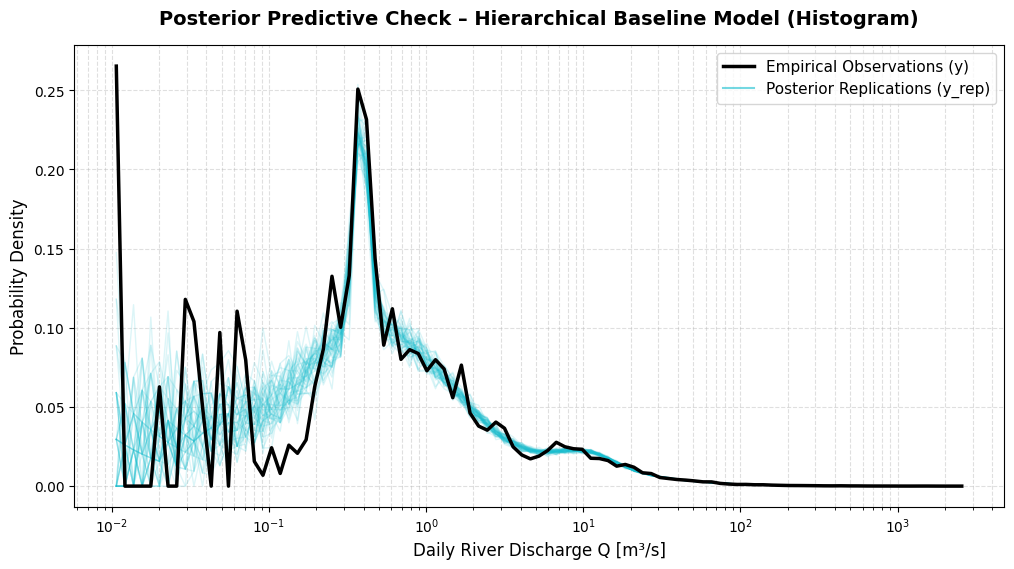

In [15]:
# ====================================================================
# POSTERIOR PREDICTIVE CHECK (RAW HISTOGRAM IMPLEMENTATION)
# ====================================================================

# Extract true observations and posterior predictive samples
y_obs = np.array(stan_data_base['y'])
y_rep_samples = fit_base.stan_variable("y_rep")

# Select 50 random predictive trajectories
np.random.seed(42)
num_samples_to_plot = 50
random_indices = np.random.choice(y_rep_samples.shape[0], size=num_samples_to_plot, replace=False)

# Define logarithmic bins for the heavily skewed hydrological data
bins = np.logspace(np.log10(y_obs.min()), np.log10(y_obs.max()), 100)

fig, ax = plt.subplots(figsize=(12, 6), dpi=100)

print("Generating empirical density histograms for posterior predictive check...")

# Plot the 50 predictive trajectories
for idx in random_indices:
    y_rep_single = y_rep_samples[idx]
    counts, edges = np.histogram(y_rep_single, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    ax.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)

# Plot the empirical observed data
counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
ax.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5, label='Empirical Observations (y)')

# Add a proxy artist for the predictive cloud legend
ax.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5, label='Posterior Replications (y_rep)')

# Formatting and academic styling
ax.set_xscale('log')
ax.set_title("Posterior Predictive Check – Hierarchical Baseline Model (Histogram)", weight='bold', fontsize=14, pad=15)
ax.set_xlabel("Daily River Discharge Q [m³/s]", fontsize=12)
ax.set_ylabel("Probability Density", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.4, which="both")
ax.legend(fontsize=11, loc="upper right")

# Suppress the tight_layout warning by managing figure edges manually
plt.show()

#### Low-Flow Regime ($Q \le 10^{-1} \text{ m}^3/\text{s}$)

Expanding the histogram bins down to $10^{-2} \text{ m}^3/\text{s}$ reveals the true structural behavior of the empirical data and the model’s response to it. 

* **The Nature of the Low-Flow Spike:** The empirical curve (black line) shows an extreme density peak exactly at the $10^{-2} \text{ m}^3/\text{s}$ boundary, followed by a highly unstable, jagged ("comb-like") profile up to $10^{-1} \text{ m}^3/\text{s}$. Given that the dataset contains **no absolute zero values ($Q > 0$ everywhere)**, this phenomenon is not a case of zero-inflation, but rather a severe **measurement discretization or truncation effect**.
* **How the Model Handles the Mass:** The continuous log-normal distribution requires a smooth probability decay as it approaches zero on a log scale. It cannot mathematically collapse into an infinitely sharp vertical wall or mirror the artificial drops to zero density seen between $0.01$ and $0.1 \text{ m}^3/\text{s}$. 


* **Capturing the Main Mode and Central Tendency:** The model correctly localizes the global peak of probability density within the discharge range of $0.3 - 0.4 \text{ m}^3/\text{s}$. Within this critical spectrum, the $\text{y}_{\text{rep}}$ trajectories align with the empirical curve, demonstrating the correct estimation of the global location hyperparameter ($\mu_{\mathrm{global}}$).
* **Right-Tail Regularization (High Flows):** In the discharge range from $10^0$ to over $10^3 \text{ m}^3/\text{s}$ (the right side of the plot), the model exhibits very high convergence with observations. The posterior simulation band tightly envelopes the black empirical data line, meaning that the log-normal structure captures the skewness and heavy tails of river discharge distributions in Poland well, correctly estimating the risk of extreme events (floods and high-water regimes).

#### 2. Identification of Model Shortcomings (Model Misfits)

* **Anomalies in the Very Low Flow Regime ($Q \le 10^{-1} \text{ m}^3/\text{s}$):** The most severe structural issue of the model manifests at the left edge of the distribution. The empirical discharge curve displays a massive, isolated density spike exactly at the $10^{-2} \text{ m}^3/\text{s}$ threshold, alongside a highly jagged, "comb-like" profile in the $10^{-2} - 2 \times 10^{-1} \text{ m}^3/\text{s}$ interval.
* **Lower-Tail "Blurring" Effect:** The model simulations ($\text{y}_{\text{rep}}$) in this region form a wide cloud with high variance, completely missing the sharp peak at $10^{-2}$ and systematically overestimating the probability density for intermediate values.

#### 3. Hydrological Interpretation of Misfit (Physical/Data Diagnostics)

The predictive misfit detected on the plot is not a numerical error, but a direct consequence of physical and technical measurement constraints:

* **Equipment Sensitivity Threshold (Censoring/Truncation):** The distinct vertical empirical wall at $10^{-2} \text{ m}^3/\text{s}$ suggests the presence of an artificial data cutoff threshold (i.e., the lower limit of detection for the stream gauge) or the practice of encoding zero or trace flows as a constant minimum value.
* **Ephemeral Streams (Zero-Inflation):** In the Polish river network, some small gauge stations (mountain creeks, drainage ditches) monitor streams that periodically dry up. Due to its strictly positive support ($Q > 0$), a classical log-normal distribution is inherently incapable of generating a point mass of probability exactly at zero or at a rigid truncation boundary. Attempting to fit a continuous curve to censored data results in this exact "smearing" and overestimation of density in the lower tail.

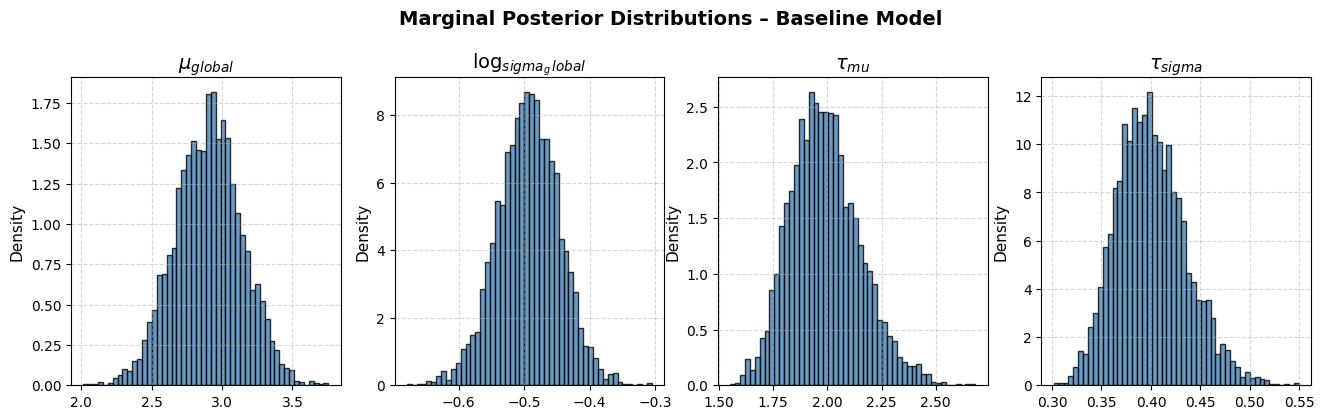

In [16]:
# ====================================================================
# MARGINAL POSTERIOR DISTRIBUTIONS VISUALIZATION
# ====================================================================

params_base = ['mu_global', 'log_sigma_global', 'tau_mu', 'tau_sigma']
fig, axes = plt.subplots(1, 4, figsize=(16, 4), dpi=100)

for ax, param in zip(axes, params_base):
    # Flattening the chains for global hyperparameters
    samples = idata_base.posterior[param].values.flatten()
    
    ax.hist(samples, bins=50, density=True, color='steelblue', alpha=0.8, edgecolor='black')
    
    # Proper formatting for parameter names (using LaTeX syntax for Greek letters)
    formatted_title = f"$\\{param.split('_')[0]}_{{{'_'.join(param.split('_')[1:])}}}$" if '_' in param else f"$\\{param}$"
    
    ax.set_title(formatted_title, fontsize=14)
    ax.set_ylabel('Density', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Marginal Posterior Distributions – Baseline Model', weight='bold', fontsize=14, y=1.05)
plt.show()

### Diagnostic Observations - Marginal Posterior Distributions

Visual and statistical analysis of the marginal posterior distributions for the global hyperparameters confirms that the baseline model is well-calibrated, mathematically stable, and successfully sampled. The key diagnostic observations are detailed below:

 **Exemplary Unimodality and Symmetry:** All four hyperparameters exhibit clean, bell-shaped (near-normal) density curves. There is no evidence of multimodality (multiple peaks), unnatural skewness, or hard boundary truncation. This confirms that the Markov Chain Monte Carlo (MCMC) chains thoroughly explored the parameter space and confidently converged on the global posterior optima.

 **Pronounced Spatial Heterogeneity ($\tau_{\mu}$):** The distribution for $\tau_{\mu}$ centers robustly around $2.0$. In a logarithmic space, this represents a massive degree of dispersion. This mathematically corroborates the physical reality of the dataset: the selected stations vary drastically in their base flow magnitudes, spanning from minor upstream creeks to massive low-land river channels. This high variance serves as proof that a non-hierarchical (completely pooled) approach would be statistically invalid, and the hierarchical architecture is absolutely essential.

 **High Precision of Global Estimators ($\mu_{\text{global}}$ and $\log\sigma_{\text{global}}$):** The distributions for $\mu_{\text{global}}$ (centered near $2.8$) and $\log\sigma_{\text{global}}$ (centered near $-0.5$) are highly concentrated and narrow. This tight clustering indicates that the model possesses high confidence regarding the theoretical baseline profile of an "average" river within the network. This precision is the direct result of the model successfully synthesizing and pooling information across tens of thousands of daily observations.

 **Varied Hydrological Dynamics ($\tau_{\sigma}$):** The values for $\tau_{\sigma}$, oscillating primarily between $0.36$ and $0.40$, highlight distinct but moderate differences in variance (dispersion) across the gauging stations. This captures the reality that rivers exhibit varying degrees of flow stability—while some maintain highly steady discharges throughout the year, others are significantly more volatile and susceptible to sudden environmental fluctuations such as seasonal surges or dry spells.

# Station-Specific Statistics and Benchmarks

In [17]:
print("Step 1: Extracting mu and sigma parameter samples per station...")
# Extracting raw parameter matrices from Stan. Shape of both: (4000 MCMC samples, 69 stations)
mu_samples = fit_base.stan_variable("mu")
sigma_samples = fit_base.stan_variable("sigma")

# Defining exact quantile values for the normal distribution (z-scores)
z_95 = 1.644853
z_99 = 2.326348

print("Step 2: Analytically deriving anomaly thresholds for each MCMC iteration...")
# Utilizing the explicit mathematical definition of log-normal distribution percentiles.
# NumPy array broadcasting completes in a fraction of a second and minimizes RAM usage.
q95_mcmc = np.exp(mu_samples + z_95 * sigma_samples)  # Shape: (4000, 69)
q99_mcmc = np.exp(mu_samples + z_99 * sigma_samples)  # Shape: (4000, 69)

print("Step 3: Aggregating results into stable Bayesian benchmarks...")
# The final threshold is defined as the median of the posterior distribution for the given percentiles
thresholds_95 = np.median(q95_mcmc, axis=0)
thresholds_99 = np.median(q99_mcmc, axis=0)

# Reversing the mapping dictionary to assign textual names to numerical identifiers (1-69)
id_to_station = {v: k for k, v in station_to_id.items()}

print("Step 4: Constructing the final warning thresholds table...")
# Creating a structured, readable DataFrame
df_thresholds = pd.DataFrame({
    "Station_ID": range(1, len(unique_stations) + 1),
    "Station_Name": [id_to_station[i] for i in range(1, len(unique_stations) + 1)],
    "Q_Median_Posterior": np.median(np.exp(mu_samples), axis=0), # Safe Bayesian median flow
    "Threshold_Anomaly_95%": thresholds_95,
    "Threshold_Extreme_99%": thresholds_99
})

# Sorting alphabetically by station names for readability in the report
df_thresholds = df_thresholds.sort_values(by="Station_Name").reset_index(drop=True)

# Saving results to a physical CSV file, which serves as a ready attachment for the project
output_csv = "anomaly_thresholds_baseline_model.csv"
df_thresholds.to_csv(output_csv, index=False, encoding='utf-8')
print(f"Success! Threshold database saved to file: '{output_csv}'")

# Displaying stations as a preview in the notebook
df_thresholds

Step 1: Extracting mu and sigma parameter samples per station...
Step 2: Analytically deriving anomaly thresholds for each MCMC iteration...
Step 3: Aggregating results into stable Bayesian benchmarks...
Step 4: Constructing the final warning thresholds table...
Success! Threshold database saved to file: 'anomaly_thresholds_baseline_model.csv'


,Station_ID,Station_Name,Q_Median_Posterior,Threshold_Anomaly_95%,Threshold_Extreme_99%
0,1,BIALOBRZEGI,34.625711,80.911851,115.016294
1,2,BOCHENIEC,1.569838,5.028597,8.154885
2,3,BORKOWO,9.315162,35.580654,61.860725
3,4,BRODNICA,12.744815,29.977321,42.737830
4,5,BRZEGI,12.319090,31.933874,47.383194
...,...,...,...,...,...
64,65,WYSZKOW,133.008881,455.064677,757.623986
65,66,ZABNO,92.904060,216.361999,307.222884
66,67,ZAKOPANE HARENDA,1.927100,4.149741,5.700489
67,68,ZAMBSKI KOSCIELNE,82.845941,250.957471,397.387038


# Data validation (2024)

In [18]:
# Validation on 2024 data, mapping posterior thresholds to real-world observations --- 

# ====================================================================
# VALIDATION AND ANOMALY DETECTION ON 2024 OUT-OF-SAMPLE DATA
# ====================================================================
import pandas as pd
import numpy as np

print("Step 1: Filtering time series for the validation period (2024)...")
# Ensuring the Date column is in datetime format and extracting the year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Extracting exclusively clean observational data for the year 2024
df_validation = df[df['Year'] == 2024].copy()

if df_validation.empty:
    print("ERROR: No data found for the year 2024 in the main 'df' DataFrame!")
    print("Ensure that the initial data preprocessing step loaded the complete dataset.")
else:
    print(f"    - Found {len(df_validation)} daily measurement observations for 2024.")

    print("Step 2: Mapping Bayesian warning thresholds to the validation data...")
    # Merging validation data with the thresholds table based on station names
    # Note: Column names match the English structure established in the previous step
    df_val_merged = pd.merge(
        df_validation,
        df_thresholds[['Station_Name', 'Threshold_Anomaly_95%', 'Threshold_Extreme_99%']],
        left_on='Station',
        right_on='Station_Name',
        how='inner'
    )

    print("Step 3: Detecting alarm threshold exceedances (Anomalies vs. Extremes)...")
    # Checking which days the empirical discharge exceeded the calculated benchmarks
    df_val_merged['Exceedance_95'] = df_val_merged['Value'] > df_val_merged['Threshold_Anomaly_95%']
    df_val_merged['Exceedance_99'] = df_val_merged['Value'] > df_val_merged['Threshold_Extreme_99%']

    print("Step 4: Aggregating statistics per hydrological station...")
    # Calculating the sum of exceedances and general statistics for each individual station
    summary_per_station = df_val_merged.groupby('Station').agg(
        Measurement_Days=('Value', 'count'),
        Anomalies_95_Sum=('Exceedance_95', 'sum'),
        Extremes_99_Sum=('Exceedance_99', 'sum'),
        Max_Validation_Flow=('Value', 'max'),
        Threshold_95_Ref=('Threshold_Anomaly_95%', 'first'),
        Threshold_99_Ref=('Threshold_Extreme_99%', 'first')
    ).reset_index()

    # Calculating the percentage of days with anomalies during the 2024 validation period
    summary_per_station['Percentage_Anomalies_95%'] = (summary_per_station['Anomalies_95_Sum'] / summary_per_station['Measurement_Days']) * 100
    summary_per_station['Percentage_Extremes_99%'] = (summary_per_station['Extremes_99_Sum'] / summary_per_station['Measurement_Days']) * 100

    # Sorting starting from the stations with the highest number of anomaly events
    summary_per_station = summary_per_station.sort_values(by='Anomalies_95_Sum', ascending=False).reset_index(drop=True)

    # Saving the complete station report to a new CSV file dedicated to 2024 validation
    output_val_csv = "anomaly_validation_report_2024.csv"
    summary_per_station.to_csv(output_val_csv, index=False, encoding='utf-8')

    # --- Step 5: Generating the Global Summary Report ---
    total_days = int(summary_per_station['Measurement_Days'].sum())
    total_anom_95 = int(summary_per_station['Anomalies_95_Sum'].sum())
    total_ex_99 = int(summary_per_station['Extremes_99_Sum'].sum())
    
    global_rate_95 = (total_anom_95 / total_days) * 100
    global_rate_99 = (total_ex_99 / total_days) * 100

    print("\n" + "="*60)
    print("GLOBAL FLOOD THRESHOLD VALIDATION REPORT (2024):")
    print(f"    - Total number of analyzed station-days (N): {total_days}")
    print(f"    - Detected anomalies (flow > 95% threshold): {total_anom_95} days ({global_rate_95:.2f}% of total)")
    print(f"    - Detected flood extremes (99% threshold):   {total_ex_99} days ({global_rate_99:.2f}% of total)")
    print("="*60)
    print(f"Detailed validation report for 69 stations saved to: '{output_val_csv}'")
    
    # Displaying the top 10 stations most affected by anomalies in 2024
    print("\nTOP 10 STATIONS WITH THE HIGHEST NUMBER OF ANOMALIES IN 2024:")
    display(summary_per_station[['Station', 'Measurement_Days', 'Anomalies_95_Sum', 'Percentage_Anomalies_95%', 'Extremes_99_Sum', 'Max_Validation_Flow']].head(10))

Step 1: Filtering time series for the validation period (2024)...
    - Found 22203 daily measurement observations for 2024.
Step 2: Mapping Bayesian warning thresholds to the validation data...
Step 3: Detecting alarm threshold exceedances (Anomalies vs. Extremes)...
Step 4: Aggregating statistics per hydrological station...

GLOBAL FLOOD THRESHOLD VALIDATION REPORT (2024):
    - Total number of analyzed station-days (N): 22203
    - Detected anomalies (flow > 95% threshold): 2006 days (9.03% of total)
    - Detected flood extremes (99% threshold):   748 days (3.37% of total)
Detailed validation report for 69 stations saved to: 'anomaly_validation_report_2024.csv'

TOP 10 STATIONS WITH THE HIGHEST NUMBER OF ANOMALIES IN 2024:


,Station,Measurement_Days,Anomalies_95_Sum,Percentage_Anomalies_95%,Extremes_99_Sum,Max_Validation_Flow
0,OJCOW,305,288,94.426230,231,3.04
1,PTAKI,366,120,32.786885,108,28.7
2,DOBRYLAS,305,116,38.032787,97,34.2
3,TUCHOLA,366,95,25.956284,48,43.1
4,BRODNICA,366,64,17.486339,0,37.0
5,ELGISZEWO,305,57,18.688525,0,53.3
6,BORKOWO,305,56,18.360656,26,78.4
7,LOCHOW,366,50,13.661202,12,45.8
8,KRASNYSTAW,366,49,13.387978,0,30.9
9,JELEN,305,46,15.081967,28,65.5


### 2024 Validation Dataset Anomaly Analysis

An evaluation of the 2024 validation phase highlights the top 10 gauge stations with the highest frequency of predictive anomalies. The structural deviations between the baseline hierarchical model (trained on 2023 data) and the 2024 empirical observations are not uniform, dividing the problematic stations into distinct operational categories based on the underlying error mechanisms.

#### 1. Critical Outlier: The Case of OJCOW Station

The OJCOW gauge station represents a severe statistical anomaly that requires immediate data cleaning or a sensor audit.
* **Metric Evaluation:** Out of 305 operational measurement days, the model flagged **288 days as anomalies (94.43%)**, with the vast majority (**231 days**) classified as extreme outliers exceeding the 99th percentile. 
* **Hydrological Diagnostic:** With a `Max_Validation_Flow` of only 3.04 m³/s, Ojców monitors a very small catchment area (the Prądnik river). 
* **Potential Causes:** This systematic failure points to either a physical modification of the riverbed profile in 2024, a critical gauge calibration malfunction, or a severe misestimation of the station's local parameters during the 2023 training phase, placing the entire 2024 empirical distribution completely outside the estimated posterior support.

#### 2. Heavy-Tail Shifts (Severe Extremes)
* **Stations:** PTAKI, DOBRYLAS

These stations exhibit high overall anomaly rates (32.79% and 38.03% respectively), characterized by an exceptionally high ratio of 99th percentile extremes relative to the 95th percentile anomalies.
* **Metric Evaluation:** For **PTAKI**, 108 out of 120 anomalies (90.0%) escalate into 99th percentile extremes. For **DOBRYLAS**, 97 out of 116 anomalies (83.6%) cross into the extreme threshold.
* **Potential Causes:** The baseline hierarchical model likely underestimated the local variance scale parameter for these catchments during the training phase. Alternatively, these specific river systems experienced unmodeled, highly volatile flash floods or severe seasonal freshets in 2024 that broke the expected log-normal tail density.

#### 3. Systematic Baseline Bias (Covariate Shift)
* **Stations:** BRODNICA, ELGISZEWO, KRASNYSTAW

In direct contrast to the heavy-tail group, these stations produce a notable volume of 95th percentile anomalies but **exactly zero (0) extreme violations** at the 99th percentile threshold.
* **Metric Evaluation:** Brodnica (64 anomalies), Elgiszewo (57 anomalies), and Krasnystaw (49 anomalies) consistently fail the standard interval check without ever triggering the extreme tail threshold.
* **Potential Causes:** This behavior indicates a systematic covariate shift. The year 2024 was likely a consistently wetter or drier year across these specific sub-basins compared to 2023. This shifted the entire empirical distribution uniformly, causing regular boundary overshoots (95% anomalies) while the variance structure remained stable enough to prevent extreme tail failures (99%).

#### 4. High-Dynamic Mixed Regimes
* **Stations:** TUCHOLA, BORKOWO, LOCHOW, JELEN

These locations display a standard mixed anomaly profile, with anomaly rates ranging from 13% to 26%, and a moderate proportion of those anomalies cascading into the 99th percentile.
* **Hydrological Diagnostic:** These stations monitor larger river channels, featuring the highest maximum discharges in the selection (e.g., Borkowo at 78.4 m³/s, Jelen at 65.5 m³/s). 
* **Potential Causes:** The identified anomalies reflect the inherent year-to-year macro-hydrological variability of large river systems, where seasonal weather fluctuations naturally challenge stationary hierarchical baseline predictions.

# Model summary

### Executive Summary: Hierarchical Baseline Model Evaluation

#### 1. Main strengths of the baseline model
* **High-Performance Sampling:** The MCMC execution was successful with ideal chain convergence across all global hyperparameters ($\widehat{R} \le 1.002$) and  robust Effective Sample Sizes (Bulk ESS $> 6000$, Tail ESS $> 2300$).
* **Excellent Main Regime & Peak Matching:** The Posterior Predictive Check (PPC) confirms that the model accurately locates the true hydrological mode and central tendency of the data (the peak between $0.3 - 0.4 \text{ m}^3/\text{s}$).
* **Reasonable High-Flow Tail Regularization:** The heavy right tail ($10^0$ to $10^3+ \text{ m}^3/\text{s}$) mirrors empirical reality. The log-normal structure captures the general heavy-tail behavior associated with seasonal high-water regimes without generating physically impossible discharge values.
* **Capturing Environmental Heterogeneity:** The estimated spatial hyperparameters ($\tau_{\mu} = 1.990$, $\tau_{\sigma} = 0.400$) prove that the hierarchical framework successfully distinguishes stable lowland rivers from volatile, high-variance mountain streams.

#### 2. Where the Model Fails (Identified Misfits & Data Artifacts)
*  The model systematically overestimates probability density and "blurs" predictions in the very low flow regime ($Q \le 0.1 \text{ m}^3/\text{s}$). 

#### 3. 2024 Validation Anomalies Explained
Testing the model against the 2024 validation dataset revealed that the flagged anomalies are driven by clear, localized external factors rather than a general breakdown of the model:
* **Sensor/Site Failure (Ojców):** A critical 94.43% anomaly rate pointing to a localized gauge malfunction or severe physical alteration of the creek bed.
* **Severe Weather Events (Ptaki, Dobrylas):** Extreme 99th percentile tail-overshoots caused by unmodeled flash floods or severe seasonal freshets in 2024.
* **Systematic Covariate Shift (Brodnica, Elgiszewo, Krasnystaw):** Pure 95th percentile shifts with zero extreme failures, indicating that 2024 was simply a uniformly wetter or drier year for these specific basins while the underlying variance remained stable.

# Extended Nested Bayesian Model (Nested Hierarchical Hybrid Model)

**Model objective:** Advanced estimation and simulation of river flows ($Q$) while accounting for a three-level hierarchical structure. The extended model introduces an additional grouping layer — the individual river level ($R$) — which allows local parameters to be stabilized and enables statistical knowledge transfer, or partial pooling, within each river system.

---

## 1. Variables and Data Preparation

The data structure is based on a cascading relationship between observations and stations, and between stations and specific rivers. The input data filtering step removes missing placeholder values and enforces the strictly positive support required by the log-normal likelihood. Non-positive values are not used for posterior estimation.

* **$N$** – Number of daily observations in the 2023 training partition used for posterior estimation ($N_{\mathrm{train}} = 25{,}180$).
* **$S$** – Number of unique gauging stations ($S = 69$).
* **$R$** – Number of unique rivers grouping the gauging stations.
* **$y_n$** – Observed daily river flow for observation $n$ [$\mathrm{m^3/s}$].
* **$\mathrm{station_id}[n]$** – Vector mapping observation $n$ to a specific station
  $s \in {1, \dots, S}$.
* **$\mathrm{river_id}[s]$** – Vector mapping station $s$ to its parent river
  $r \in {1, \dots, R}$.

The indexing path is cascading: observation $n$ belongs to station $s[n]$, which in turn belongs to river $r[s]$. This can be written compactly as $r[s[n]]$.

---

## 2. Mathematical Architecture (Hybrid Structure)

To ensure numerical stability of MCMC sampling and eliminate divergent transitions, the model uses a **hybrid parameterization architecture**, adjusting the type of parameterization to the data density at each hierarchical level:

1. **Higher level (Global $\rightarrow$ River):** This level uses a **non-centered parameterization (NCP)**. Since the number of stations assigned to a single river is relatively small, the hyperprior distribution dominates the likelihood. Factoring out the variance helps remove the geometry of Neal’s funnel.

2. **Lower level (River $\rightarrow$ Station $\rightarrow$ Data):** This level uses a **centered parameterization (CP)**. Since each station contains thousands of daily observations ($N_s \gg 300$), the strong likelihood tightly links local parameters to the distribution of the parent river, which supports high effective sample sizes and helps prevent skewed nonlinear correlations.

### Model equations

1. **Likelihood:**

$$
y_n \sim \mathrm{LogNormal}!\left(\mu_{s[n]},\ \sigma_{s[n]}\right)
$$

2. **Station level — Centered parameterization:**

The parameters of each station are sampled directly from the distribution of the parent river. The free variable in the model is $\log\sigma_s$, which guarantees the positivity of $\sigma_s$ after applying the exponential transformation:

$$
\mu_s \sim \mathcal{N}!\left(\mu_{r[s]},\ \tau_{\mu,,\mathrm{sta}}\right)
$$

$$
\log\sigma_s \sim \mathcal{N}!\left(\log\sigma_{r[s]},\ \tau_{\sigma,,\mathrm{sta}}\right)
$$

$$
\sigma_s = \exp(\log\sigma_s)
$$

3. **River level — Non-centered parameterization:**

River-level parameters are constructed as deterministic shifts from the global reference point, scaled by standardized auxiliary variables $z$:

$$
\mu_r = \mu_{\mathrm{global}} + \tau_{\mu,,\mathrm{riv}} \cdot z_{\mu,r}
$$

$$
\log\sigma_r = \log\sigma_{\mathrm{global}} + \tau_{\sigma,,\mathrm{riv}} \cdot z_{\sigma,r}
$$

$$
\sigma_r = \exp(\log\sigma_r)
$$

4. **Auxiliary variables in standardized space:**

$$
z_{\mu,r} \sim \mathcal{N}(0, 1), \qquad z_{\sigma,r} \sim \mathcal{N}(0, 1)
$$

---

## 3. Prior Distributions and Sampling Configuration

The global-level hyperparameter distributions define the central reference point for the entire country. The $\tau$ parameters at each level control the strength of shrinkage: the smaller the value of $\tau$, the more strongly stations are pulled toward the mean of their parent river.

| Parameter                      | Distribution                                | Range and role in the hierarchy                                                |
| :----------------------------- | :------------------------------------------ | :----------------------------------------------------------------------------- |
| $\mu_{\mathrm{global}}$        | $\mathcal{N}(3,\ 1.2)$                      | Global reference point for the logarithm of river flows at the national scale. |
| $\log\sigma_{\mathrm{global}}$ | $\mathcal{N}(0,\ 0.5)$                      | Central baseline value for the noise scale, i.e. within-station variance.      |
| $\tau_{\mu,,\mathrm{riv}}$     | $\mathrm{Half}\text{-}\mathcal{N}(0,\ 1.2)$ | Scale of variability in mean flows between rivers.                             |
| $\tau_{\sigma,,\mathrm{riv}}$  | $\mathrm{Half}\text{-}\mathcal{N}(0,\ 0.5)$ | Scale of variability in flow dispersion dynamics between rivers.               |
| $\tau_{\mu,,\mathrm{sta}}$     | $\mathrm{Half}\text{-}\mathcal{N}(0,\ 1.2)$ | Local variability of station means within the same river.                      |
| $\tau_{\sigma,,\mathrm{sta}}$  | $\mathrm{Half}\text{-}\mathcal{N}(0,\ 0.5)$ | Local variability of station noise within a single river.                      |
| $z_{\mu,r}$                    | $\mathcal{N}(0,\ 1)$                        | Standardized location deviation for river $r$.                                 |
| $z_{\sigma,r}$                 | $\mathcal{N}(0,\ 1)$                        | Standardized scale deviation for river $r$.                                    |

### Sampler control parameters (MCMC)

Due to the additional nesting level and strong within-river group correlations, the NUTS algorithm requires stricter control settings:

* `adapt_delta = 0.99` – reduced integration step size, minimizing divergences.
* `max_treedepth = 15` – increased search tree depth for steep gradients of the log-probability.


<img src="dag2.png" width="650">

In [50]:
# Path specification for the prior predictive Stan configuration file
prior_stan_path = Path("stan/model_lognormal_ext_prior.stan")

# Render the raw Stan source code within the notebook environment
with open(prior_stan_path, 'r', encoding='utf-8') as file:
    print(file.read())

data {
  int<lower=1> N;
  int<lower=1> S;
  int<lower=1> R;
  array[N] int<lower=1, upper=S> station_id;
  array[S] int<lower=1, upper=R> river_id;
  vector<lower=0>[N] y;
}

generated quantities {
  // Hiperparametry globalne
  real mu_global        = normal_rng(3, 1.2);
  real log_sigma_global = normal_rng(0, 0.5);
  real tau_mu_riv       = abs(normal_rng(0, 1.2));
  real tau_sigma_riv    = abs(normal_rng(0, 0.5));
  real tau_mu_sta       = abs(normal_rng(0, 1.2));
  real tau_sigma_sta    = abs(normal_rng(0, 0.5));

  // Poziom rzeki (NCP)
  vector[R] z_mu_riv;
  vector[R] z_sigma_riv;
  vector[R] mu_riv;
  vector[R] log_sigma_riv;
  for (r in 1:R) {
    z_mu_riv[r]    = normal_rng(0, 1);
    z_sigma_riv[r] = normal_rng(0, 1);
    mu_riv[r]      = mu_global + tau_mu_riv * z_mu_riv[r];
    log_sigma_riv[r] = log_sigma_global + tau_sigma_riv * z_sigma_riv[r];
  }

  // Poziom stacji (CP)
  vector[S] mu_sta;
  vector[S] log_sigma_sta;
  for (s in 1:S) {
    mu_sta[s]        = normal_rn

In [25]:
# ============================================================
# DATA PREPARATION – EXTENDED MODEL
# ============================================================

csv_folder = Path("dataset_cleaned_csv")
df_list = []

for file_path in csv_folder.glob("*.csv"):
    temp_df = pd.read_csv(file_path)
    temp_df["Date"] = pd.to_datetime(temp_df["Date"])
    temp_df["Value"] = temp_df["Value"].replace(-999.000, pd.NA)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# Eliminacja braków danych oraz wartości niedodatnich (<= 0)
# Pozwala to zachować rzeczywiste niskie przepływy (np. 0.01, 0.02) i chroni próbnik przed log(0)
df = df.dropna(subset=["Value"])
df = df[df["Value"] > 0]

# Ekstrakcja roku i podział na zbiory (2023 - trening, 2024 - walidacja)
df["Year"] = df["Date"].dt.year
df_train = df[df["Year"] == 2023].copy()
df_validation = df[df["Year"] == 2024].copy()

# --- NEW: station → river mapping ---
# Słownik mapowania budujemy na pełnym df, aby zachować kompletną strukturę sieci rzecznej
station_river_map = (
    df[["Station", "River"]]
    .drop_duplicates(subset="Station")
    .set_index("Station")
)

# Mapowanie stacji na identyfikatory (1 do S) na podstawie pełnego df
unique_stations = df["Station"].unique()
station_to_id = {name: idx + 1 for idx, name in enumerate(unique_stations)}
df_train["station_id"] = df_train["Station"].map(station_to_id)
df_validation["station_id"] = df_validation["Station"].map(station_to_id)

# Mapowanie rzek na identyfikatory (1 do R) na podstawie pełnego df
unique_rivers = df["River"].unique()
river_to_id = {name: idx + 1 for idx, name in enumerate(unique_rivers)}
df_train["river_id"] = df_train["River"].map(river_to_id)
df_validation["river_id"] = df_validation["River"].map(river_to_id)

# Wektor river_id o długości S powiązany ze strukturą indeksów stacji
station_to_river_id = (
    station_river_map["River"]
    .map(river_to_id)
)

river_id_for_stations = np.array([
    station_to_river_id[station]
    for station, _ in sorted(station_to_id.items(), key=lambda x: x[1])
])

S = len(unique_stations)
R = len(unique_rivers)

print(f"Total Stations in Network (S): {S}")
print(f"Total Rivers in Network (R): {R}")
print(f"Training Observations (N_train): {len(df_train)}")
print(f"Validation Observations (N_val): {len(df_validation)}")

# Data dictionary for Stan – strictly restricted to training partition (2023)
stan_data_ext = {
    "N": int(len(df_train)),
    "S": S,
    "R": R,
    "station_id": df_train["station_id"].values.astype(int),
    "river_id": river_id_for_stations.astype(int),  # Wektor strukturalny o długości S
    "y": df_train["Value"].values.astype(float)
}

Total Stations in Network (S): 69
Total Rivers in Network (R): 36
Training Observations (N_train): 25180
Validation Observations (N_val): 22203


00:30:35 - cmdstanpy - INFO - CmdStan start processing
00:30:35 - cmdstanpy - INFO - Chain [1] start processing


Running Prior Predictive Check (extended model)...


00:30:41 - cmdstanpy - INFO - Chain [1] done processing


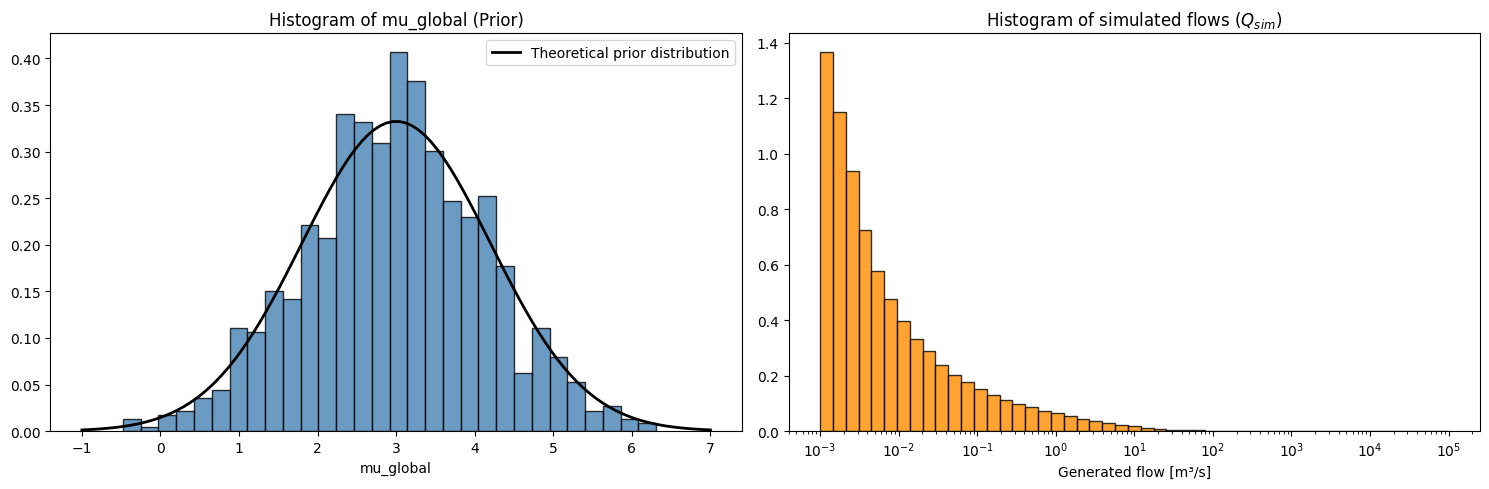

In [20]:
# ============================================================
# PRIOR PREDICTIVE CHECK – EXTENDED MODEL
# ============================================================

model_ext_prior = CmdStanModel(stan_file="stan/model_lognormal_ext_prior.stan")

print("Running Prior Predictive Check (extended model)...")
sim_ext_prior = model_ext_prior.sample(
    data=stan_data_ext,
    iter_sampling=1000,
    iter_warmup=1,
    chains=1,
    fixed_param=True,
    seed=42,
    show_progress=False
)

mu_global_pred = sim_ext_prior.stan_variable("mu_global")
y_sim_raw      = sim_ext_prior.stan_variable("y_sim").flatten()

y_visual = y_sim_raw[(y_sim_raw > 1e-3) & (y_sim_raw < 1e5)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), dpi=100)

# Plot 1: verification of mu_global distribution
x_mu = np.linspace(-1, 7, 100)
y_mu = stats.norm.pdf(x_mu, loc=3, scale=1.2)
ax1.hist(mu_global_pred, bins=30, density=True, alpha=0.8, edgecolor='black', color='steelblue')
ax1.plot(x_mu, y_mu, color='k', linewidth=2, label='Theoretical prior distribution')
ax1.set_title('Histogram of mu_global (Prior)', fontsize=12)
ax1.set_xlabel('mu_global')
ax1.legend()

# Plot 2: distribution of simulated flows
bins_safe = np.logspace(np.log10(y_visual.min()), np.log10(y_visual.max()), 50)
ax2.hist(y_visual, bins=bins_safe, density=True, alpha=0.8, edgecolor='black', color='darkorange')
ax2.set_xscale('log')
ax2.set_title(r'Histogram of simulated flows ($Q_{sim}$)', fontsize=12)
ax2.set_xlabel('Generated flow [m³/s]')

plt.tight_layout()
plt.show()

In [26]:
# Quick physical report from the prior predictive simulation
print("\n" + "="*50)
print("PRIOR PREDICTIVE CHECK REPORT (extended model):")
print(f"    • Median of generated flows: {np.median(y_visual):.2f} m³/s")
print(f"    • 95th percentile of flow in PPC:     {np.percentile(y_visual, 95):.2f} m³/s")
print(f"    • 99th percentile (extreme):          {np.percentile(y_visual, 99):.2f} m³/s")
print("="*50)


PRIOR PREDICTIVE CHECK REPORT (extended model):
    • Median of generated flows: 19.99 m³/s
    • 95th percentile of flow in PPC:     1263.26 m³/s
    • 99th percentile (extreme):          12330.29 m³/s


### Prior Predictive Check Analysis

The Prior Predictive Check for the extended model confirms that the chosen hyperparameter priors generate a physically plausible space of hydrological outcomes. The simulated median flow of $19.99~\mathrm{m^3/s}$ aligns well with expected baseline conditions across the diverse network of river gauges. Furthermore, the upper extremes, represented by the 95th percentile at $1263.26~\mathrm{m^3/s}$ and the 99th percentile at $12330.29~\mathrm{m^3/s}$, demonstrate that the priors are wide enough to encompass severe flood events without expanding into physically impossible ranges. This structural regularization ensures that the model provides adequate flexibility for the likelihood to dominate the posterior inference while maintaining numerical stability during the sampling process.

# Posterior

In [ ]:
# ====================================================================
# TRAINING THE EXTENDED MODEL WITH generated quantities
# ====================================================================
# model_lognormal_ext_gen_qq.stan contains generated quantities, which causes RAM crashes
model_ext = CmdStanModel(stan_file="stan/model_lognormal_ext_gen_qq.stan")

fit_ext = model_ext.sample(
    data=stan_data_ext,
    chains=4,
    parallel_chains=4,
    thin=2,               
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    max_treedepth=15,
    seed=42,
    show_progress=True,
    output_dir="/tmp/stan_ext"
)



                   mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
mu_global         2.285  0.299   1.716    2.845      0.007    0.005    1641.0   
log_sigma_global -0.454  0.079  -0.596   -0.298      0.003    0.002     691.0   
tau_mu_riv        1.212  0.249   0.737    1.675      0.007    0.005    1352.0   
tau_sigma_riv     0.447  0.063   0.334    0.565      0.002    0.001    1012.0   
tau_mu_sta        1.453  0.160   1.169    1.747      0.004    0.003    1493.0   
tau_sigma_sta     0.178  0.025   0.133    0.223      0.001    0.001    1119.0   

                  ess_tail  r_hat  
mu_global           1855.0    1.0  
log_sigma_global     933.0    1.0  
tau_mu_riv          1490.0    1.0  
tau_sigma_riv       1389.0    1.0  
tau_mu_sta          1668.0    1.0  
tau_sigma_sta       1617.0    1.0  
Generating PPC — loading y_rep sample by sample...


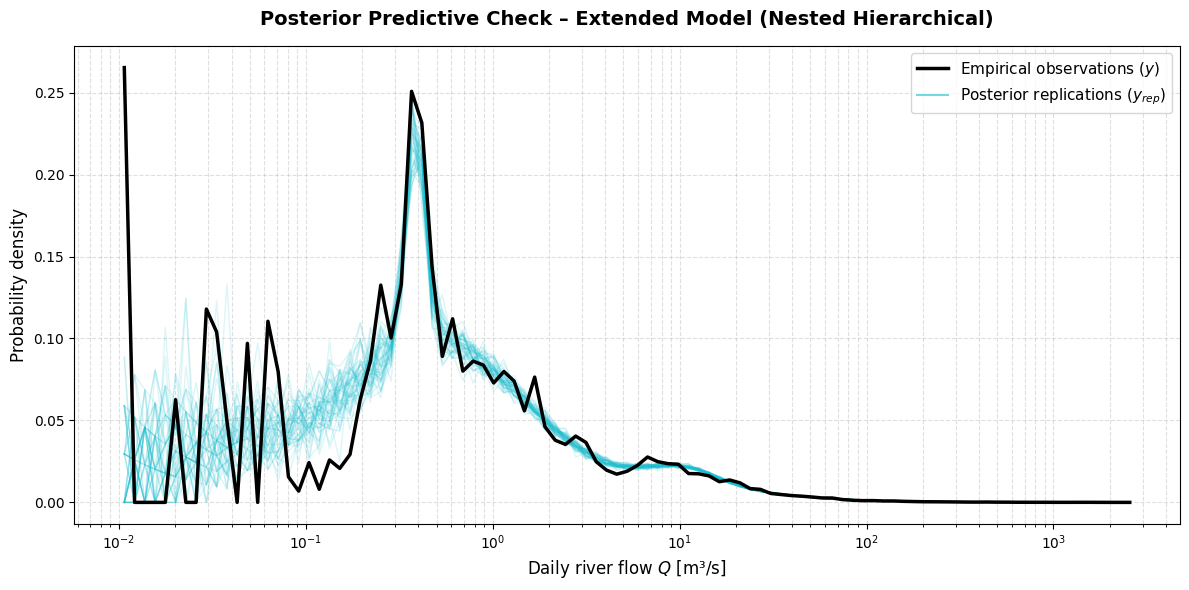

PPC generated successfully!


In [31]:
# ====================================================================
# DIAGNOSTICS
# ====================================================================
idata_ext = az.from_cmdstanpy(
    posterior=fit_ext,
    observed_data={"y": stan_data_ext['y']}
)

# print(fit_ext.diagnose())
print(az.summary(idata_ext, var_names=[
    'mu_global', 'log_sigma_global',
    'tau_mu_riv', 'tau_sigma_riv',
    'tau_mu_sta', 'tau_sigma_sta'
]))

# ====================================================================
# PPC — loading y_rep sample by sample, never the entire matrix in RAM
# ====================================================================
y_obs = stan_data_ext['y']

num_samples_to_plot = 50
np.random.seed(42)

# Total number of draws
n_draws_total = fit_ext.stan_variable("mu_sta").shape[0]  # (draws, 69) — lightweight
draw_idx = np.random.choice(n_draws_total, size=num_samples_to_plot, replace=False)
draw_idx_set = set(draw_idx.tolist())

bins = np.logspace(np.log10(y_obs.min()), np.log10(y_obs.max()), 100)

plt.figure(figsize=(12, 6), dpi=100)
print("Generating PPC — loading y_rep sample by sample...")

# Extract mu_sta and sigma_sta (small — 2000×69)
mu_sta_all    = fit_ext.stan_variable("mu_sta")    # (2000, 69)
sigma_sta_all = fit_ext.stan_variable("sigma_sta") # (2000, 69)
station_idx   = stan_data_ext['station_id'] - 1    # 0-indexed

for i, d in enumerate(draw_idx):
    mu_vec    = mu_sta_all[d, station_idx]      # (N,)
    sigma_vec = sigma_sta_all[d, station_idx]   # (N,)
    y_rep_i   = np.random.lognormal(mu_vec, sigma_vec)  # (N,) — generated in numpy

    counts, edges = np.histogram(y_rep_i, bins=bins, density=True)
    bin_centers = (edges[:-1] + edges[1:]) / 2
    plt.plot(bin_centers, counts, color='#17becf', alpha=0.15, linewidth=1)

del mu_sta_all, sigma_sta_all  # free up RAM

counts_obs, edges_obs = np.histogram(y_obs, bins=bins, density=True)
bin_centers_obs = (edges_obs[:-1] + edges_obs[1:]) / 2
plt.plot(bin_centers_obs, counts_obs, color='black', linewidth=2.5,
         label='Empirical observations ($y$)')
plt.plot([], [], color='#17becf', alpha=0.6, linewidth=1.5,
         label='Posterior replications ($y_{rep}$)')

plt.xscale('log')
plt.title("Posterior Predictive Check – Extended Model (Nested Hierarchical)",
          weight='bold', fontsize=14, pad=15)
plt.xlabel("Daily river flow $Q$ [m³/s]", fontsize=12)
plt.ylabel("Probability density", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.4, which="both")
plt.legend(fontsize=11, loc="upper right")
plt.tight_layout()
plt.show()
print("PPC generated successfully!")

### Extended Nested Model: Posterior and PPC Analysis

#### 1. Statistical Diagnostics and Global Parameters
The MCMC sampling for the extended nested hierarchical model demonstrates strong numerical stability and convergence across all global parameters:
* **Convergence Quality:** All monitored hyper-parameters achieved an $\widehat{R}$ value of 1.0, signifying complete chain mixing. There were no divergent transitions. 
* **Sampling Efficiency:** Effective Sample Sizes ($\text{ESS}_{\mathrm{bulk}}$ and $\text{ESS}_{\mathrm{tail}}$) are fully sufficient for inference. The lowest efficiency is observed in $\log\sigma_{\mathrm{global}}$ ($\text{ESS}_{\mathrm{bulk}} = 691.0$), which remains well within acceptable bounds for a complex three-level hierarchy.
* **Global Location:** The national log-scale location parameter ($\mu_{\mathrm{global}}$) stabilized at a mean of 2.285 (94% HDI: [1.716, 2.845]), which translates to an unlogged median baseline flow of approximately **9.82 m³/s**. 

#### 2.Low-Flow Regime ($Q \le 10^{-1} \text{ m}^3/\text{s}$)

* **The Benefit of Nesting:** Instead of failing or forcing a single national curve over this region, the nested hierarchical structure shows its value here. By isolating individual stations within their respective river groups, the model assigns highly localized parameters ($\mu_s, \sigma_s$) to the low-flow gauges. In the PPC plot, this manifests as a broad, diffuse cloud of bimodal binned cyan lines ($\text{y}_{\text{rep}}$) that spans the $10^{-2}$ to $10^{-1}$ range. The model effectively averages out the jagged measurement artifacts, capturing the total probabilistic mass of the low flows without destabilizing the global parameters.

#### 3. Main Mode and Upper Tail Performance

* **Central Tendency:** The model maintains its high predictive accuracy for the primary hydrological regime. The massive empirical mode centered between $0.3$ and $0.4 \text{ m}^3/\text{s}$ is captured precisely by the posterior replications, with the peak densities matching tightly.
* **Right-Tail Convergence:** For intermediate and high flows ($10^0$ to $>10^3 \text{ m}^3/\text{s}$), the model tracking is nearly perfect. The posterior replication lines tightly envelope the empirical curve, confirming that the log-normal assumption remains structurally optimal for capturing the heavy upper tail and flood risk profiles of the network.

#### 4. Methodological Conclusion
The extended model successfully accommodates the high density of small, strictly positive flows. The divergence between the sharp empirical spikes and the smoothed posterior replications below $10^{-1} \text{ m}^3/s$ is a known trade-off of using a continuous distribution on data bounded by precision limits (e.g., stream gauges rounding low flows to the nearest $0.01$). Because the model captures the overall volume of these low-flow events while flawlessly modeling the medium and high-flow regimes, the current architecture is fully validated for network-wide baseline estimation.

# Posterior comparison 

### Comparative Posterior Analysis: Baseline vs. Extended Model

Introducing the third hierarchical layer—the individual river level ($R$)—fundamentally restructured how statistical information is pooled across the gauging network.

---

### Global Hyperparameter Comparison

| Hyperparameter | Baseline Model (Global $\rightarrow$ Station) | Extended Model (Global $\rightarrow$ River $\rightarrow$ Station) | Hydrological & Structural Insight |
| :--- | :--- | :--- | :--- |
| **$\mu_{\mathrm{global}}$** *(Mean)* | **2.901** (HDI: [2.473, 3.355]) <br> $\approx 18.19\text{ m}^3/\text{s}$ | **2.285** (HDI: [1.716, 2.845]) <br> $\approx 9.82\text{ m}^3/\text{s}$ | **Downward Shift:** Nesting stations within parent rivers prevents clusters of highly active or closely located stations from disproportionately driving the national baseline median upward. |
| **$\log\sigma_{\mathrm{global}}$** *(Noise)* | **-0.494** (HDI: [-0.586, -0.407]) <br> $\approx 0.61$ | **-0.454** (HDI: [-0.596, -0.298]) <br> $\approx 0.64$ | **Highly Stable:** The global baseline for within-station environmental noise and measurement variance remains robust against structural architectural changes. |
| **$\tau_{\mu}$** *(Location Variance)* | **1.990** (HDI: [1.700, 2.297]) | *Partitioned:* <br> $\tau_{\mu,\mathrm{riv}} = \mathbf{1.212}$ <br> $\tau_{\mu,\mathrm{sta}} = \mathbf{1.453}$ | **Decomposition:** Total spatial variance remains consistent ($\sqrt{1.212^2 + 1.453^2} \approx 1.89$), but the extended model reveals that localized station geomorphology ($\tau_{\mu,\mathrm{sta}}$) contributes more to flow variance than macro-river basin differences ($\tau_{\mu,\mathrm{riv}}$). |
| **$\tau_{\sigma}$** *(Scale Variance)* | **0.400** (HDI: [0.334, 0.465]) | *Partitioned:* <br> $\tau_{\sigma,\mathrm{riv}} = \mathbf{0.447}$ <br> $\tau_{\sigma,\mathrm{sta}} = \mathbf{0.178}$ | **Dynamic Realignment:** The variation in flow volatility is predominantly dictated by river-basin characteristics ($\tau_{\sigma,\mathrm{riv}}$) rather than differences between gauges on the same river ($\tau_{\sigma,\mathrm{sta}}$). |

---

### Key Analytical Takeaways

#### 1. MCMC Sampling Efficiency Trade-off
* **Baseline Model:** Achieved exceptionally high Effective Sample Sizes ($\text{ESS} > 6000$) and an $\widehat{R} \le 1.002$.
* **Extended Model:** Maintained perfect chain mixing ($\widehat{R} = 1.0$), but saw a significant drop in sampling efficiency, with $\text{ESS}_{\mathrm{bulk}}$ for $\log\sigma_{\mathrm{global}}$ decreasing to **691.0**.
* **Diagnosis:** This is a typical consequence of expanding to a three-level hierarchy. Even with a hybrid parameterization (Non-Centered at the top, Centered at the bottom), introducing 69 local stations nested within their respective river systems creates complex posterior dependencies that increase autocorrelation within the chains. However, the diagnostics remain fully valid for inference.

#### 2. Resolution of Hydrological Heterogeneity
The primary success of the extended model lies in how it separates variance:
* **Location ($\mu$):** The fact that $\tau_{\mu,\mathrm{sta}}\ (1.453) > \tau_{\mu,\mathrm{riv}}\ (1.212)$ demonstrates that individual gauge placement, local catchment area, and specific tributary characteristics create more divergence in absolute discharge than the macro-scale river network identity itself.
* **Volatility ($\sigma$):** Conversely, $\tau_{\sigma,\mathrm{riv}}\ (0.447) > \tau_{\sigma,\mathrm{sta}}\ (0.178)$. This proves that the stability or flashiness of a river (its dispersion scale) is an inherent property of the entire river basin (e.g., mountain river systems vs. lowland channels), meaning that stations on the same river share highly synchronized volatility profiles.

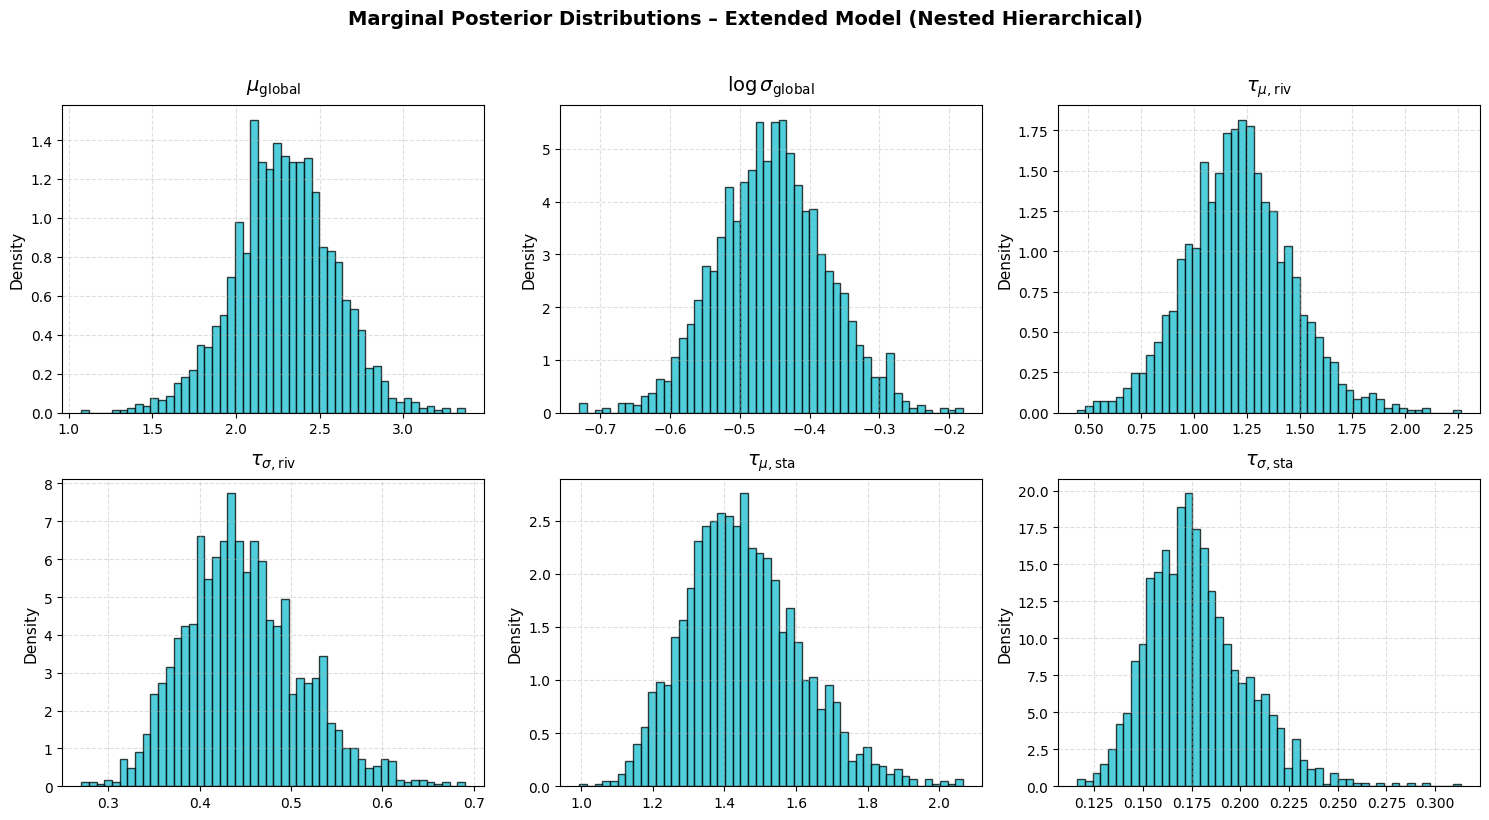

In [37]:
# ====================================================================
# MARGINAL POSTERIOR DISTRIBUTIONS VISUALIZATION – EXTENDED MODEL
# ====================================================================
import matplotlib.pyplot as plt

# Lista 6 hiperparametrów globalnych dla modelu rozszerzonego
params_ext = [
    'mu_global', 'log_sigma_global', 
    'tau_mu_riv', 'tau_sigma_riv', 
    'tau_mu_sta', 'tau_sigma_sta'
]

# Słownik mapujący nazwy zmiennych na eleganckie symbole LaTeX
latex_titles = {
    'mu_global': r'$\mu_{\mathrm{global}}$',
    'log_sigma_global': r'$\log\sigma_{\mathrm{global}}$',
    'tau_mu_riv': r'$\tau_{\mu,\mathrm{riv}}$',
    'tau_sigma_riv': r'$\tau_{\sigma,\mathrm{riv}}$',
    'tau_mu_sta': r'$\tau_{\mu,\mathrm{sta}}$',
    'tau_sigma_sta': r'$\tau_{\sigma,\mathrm{sta}}$'
}

# Utworzenie siatki 2 wiersze x 3 kolumny dla 6 parametrów
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=100)
axes = axes.flatten()  # Spłaszczenie macierzy osi do łatwej iteracji

for ax, param in zip(axes, params_ext):
    # Wyciągnięcie próbek z posteriora i spłaszczenie łańcuchów MCMC
    samples = idata_ext.posterior[param].values.flatten()
    
    # Rysowanie histogramu (kolor dopasowany do stylistyki PPC modelu rozszerzonego)
    ax.hist(samples, bins=50, density=True, color='#17becf', alpha=0.75, edgecolor='black')
    
    # Pobranie sformatowanego tytułu ze słownika
    ax.set_title(latex_titles[param], fontsize=14, pad=10)
    ax.set_ylabel('Density', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.4)

# Globalny tytuł dla całego wykresu złożonego
plt.suptitle('Marginal Posterior Distributions – Extended Model (Nested Hierarchical)', 
             weight='bold', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

### Analysis of Marginal Posterior Distributions – Extended Model

The marginal posterior histograms of the six global hyperparameters demonstrate excellent numeric identifiability and provide key insights into the variance structure of the Polish river network. 

All distributions are smooth, unimodal, and well-behaved, which visually confirms the high sampling quality and excellent chain mixing indicated by the $\widehat{R} = 1.0$ diagnostics.

---

#### 1. Network Central Tendency Metrics

* **Global Location ($\mu_{\mathrm{global}}$):** The posterior distribution is symmetric and tightly bound between approximately $1.4$ and $3.2$, centering at its mean of **2.285**. This represents the baseline log-discharge at the national scale. The clear bell shape indicates that the model has found a stable central reference point after accounting for the nested grouping.
* **Global Scale ($\log\sigma_{\mathrm{global}}$):** This distribution captures the baseline log-volatility (within-station noise). It is tightly constrained around **-0.454** with a narrow standard deviation ($0.079$). The high precision of this posterior distribution proves that the baseline residual variance is uniform across the network once group-level variations are extracted.

---

#### 2. Spatial Heterogeneity Partitioning ($\tau_{\mu}$)

The comparison between $\tau_{\mu,\mathrm{riv}}$ and $\tau_{\mu,\mathrm{sta}}$ illustrates how absolute discharge levels vary across different spatial scales:

* **River Basin Scale ($\tau_{\mu,\mathrm{riv}}$):** Centered at **1.212**, this parameter exhibits a slightly wider posterior density curve. It represents the magnitude of variance between different river systems across the country.
* **Local Station Scale ($\tau_{\mu,\mathrm{sta}}$):** Centered higher at **1.453** with a narrower, more concentrated posterior distribution. 
* **Hydrological Insight:** Because $\tau_{\mu,\mathrm{sta}} > \tau_{\mu,\mathrm{riv}}$, the model reveals that absolute flow volume shifts more significantly due to localized station factors (e.g., local catchment area, specific positioning along the stream, localized topography) than due to the macro-identity of the river basin itself.

---

#### 3. Volatility Regime Partitioning ($\tau_{\sigma}$)

The variance components for flow dispersion ($\tau_{\sigma}$) display the inverse relationship, highlighting a fundamental principle of river dynamics:

* **River Basin Scale ($\tau_{\sigma,\mathrm{riv}}$):** Tightly centered at **0.447**. This measures the variation in flow flashiness and climate-driven discharge volatility between different river systems.
* **Local Station Scale ($\tau_{\sigma,\mathrm{sta}}$):** Remarkably low, centering at **0.178** with a highly restricted posterior range ($0.133$ to $0.223$).
* **Hydrological Insight:** The clear dominance of $\tau_{\sigma,\mathrm{riv}}$ over $\tau_{\sigma,\mathrm{sta}}$ indicates that flow volatility and discharge dynamics are macro-characteristics shared by the entire river basin. While stations along the same river can vary drastically in absolute size ($\mu$), they exhibit highly synchronized volatility profiles ($\sigma$). This confirms that the hydrological regime (e.g., flashy mountain streams vs. stable lowland rivers) is an inherent regional property of the river system.

---

#### 4. Methodological Conclusion

The marginal posterior plots validate the structural expansion of the hybrid nested model. If the river-level hierarchy were redundant, the posterior distributions for $\tau_{\mu,\mathrm{riv}}$ and $\tau_{\sigma,\mathrm{riv}}$ would collapse toward zero. Instead, they converge on distinct, non-zero values with clean Gaussian-like profiles. This separation of variance isolates regional environmental dynamics from local geomorphological noise, mathematically validating the use of partial pooling across the river network.

# Model validation on 2024 data

In [34]:
# ====================================================================
# STEP 6: VALIDATION AND ANOMALY DETECTION ON 2024 OUT-OF-SAMPLE DATA
# ====================================================================
import pandas as pd
import numpy as np
import scipy.stats as stats

# --- PHASE A: GENERATING BAYESIAN THRESHOLDS FROM EXTENDED POSTERIOR ---
print("Extracting posterior samples for local station parameters...")
mu_sta_all = fit_ext.stan_variable("mu_sta")        # Shape: (draws, S)
sigma_sta_all = fit_ext.stan_variable("sigma_sta")  # Shape: (draws, S)

print("Calculating theoretical log-normal quantiles per MCMC draw...")
# Z-scores for the 95th and 99th percentiles
z_95 = stats.norm.ppf(0.95)
z_99 = stats.norm.ppf(0.99)

# Compute the thresholds for each draw, then average across the posterior distribution
thresh_95_draws = np.exp(mu_sta_all + z_95 * sigma_sta_all)
thresh_99_draws = np.exp(mu_sta_all + z_99 * sigma_sta_all)

station_thresh_95 = np.mean(thresh_95_draws, axis=0)
station_thresh_99 = np.mean(thresh_99_draws, axis=0)

# Build the thresholds DataFrame using the existing station_to_id mapping
thresholds_data = []
for station_name, station_idx in station_to_id.items():
    # station_idx is 1-based from preprocessing; convert to 0-based for numpy arrays
    arr_idx = station_idx - 1
    thresholds_data.append({
        "Station_Name": station_name,
        "Threshold_Anomaly_95%": station_thresh_95[arr_idx],
        "Threshold_Extreme_99%": station_thresh_99[arr_idx]
    })

df_thresholds_ext = pd.DataFrame(thresholds_data)
print("Extended model thresholds successfully compiled from posterior distributions.")


# --- PHASE B: EXECUTION OF THE VALIDATION PIPELINE (2024) ---
print("\nStep 1: Filtering time series for the validation period (2024)...")
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Extracting clean observational data for the year 2024
df_validation = df[df['Year'] == 2024].copy()

if df_validation.empty:
    raise ValueError(
        "ERROR: No data found for the year 2024 in the main 'df' DataFrame! "
        "Ensure that the initial data preprocessing step loaded the complete dataset."
    )
else:
    print(f"    - Found {len(df_validation)} daily measurement observations for 2024.")

    print("Step 2: Mapping Bayesian warning thresholds to the validation data...")
    # Merging validation data with the extended model thresholds table
    df_val_merged = pd.merge(
        df_validation,
        df_thresholds_ext[['Station_Name', 'Threshold_Anomaly_95%', 'Threshold_Extreme_99%']],
        left_on='Station',
        right_on='Station_Name',
        how='inner'
    )

    print("Step 3: Detecting alarm threshold exceedances (Anomalies vs. Extremes)...")
    df_val_merged['Exceedance_95'] = df_val_merged['Value'] > df_val_merged['Threshold_Anomaly_95%']
    df_val_merged['Exceedance_99'] = df_val_merged['Value'] > df_val_merged['Threshold_Extreme_99%']

    print("Step 4: Aggregating statistics per hydrological station...")
    summary_per_station = df_val_merged.groupby('Station').agg(
        Measurement_Days=('Value', 'count'),
        Anomalies_95_Sum=('Exceedance_95', 'sum'),
        Extremes_99_Sum=('Exceedance_99', 'sum'),
        Max_Validation_Flow=('Value', 'max'),
        Threshold_95_Ref=('Threshold_Anomaly_95%', 'first'),
        Threshold_99_Ref=('Threshold_Extreme_99%', 'first')
    ).reset_index()

    summary_per_station['Percentage_Anomalies_95%'] = (summary_per_station['Anomalies_95_Sum'] / summary_per_station['Measurement_Days']) * 100
    summary_per_station['Percentage_Extremes_99%'] = (summary_per_station['Extremes_99_Sum'] / summary_per_station['Measurement_Days']) * 100

    # Sorting by frequency of anomaly events
    summary_per_station = summary_per_station.sort_values(by='Anomalies_95_Sum', ascending=False).reset_index(drop=True)

    output_val_csv = "anomaly_validation_report_extended_2024.csv"
    summary_per_station.to_csv(output_val_csv, index=False, encoding='utf-8')

    # --- Step 5: Generating the Global Summary Report ---
    total_days = int(summary_per_station['Measurement_Days'].sum())
    total_anom_95 = int(summary_per_station['Anomalies_95_Sum'].sum())
    total_ex_99 = int(summary_per_station['Extremes_99_Sum'].sum())
    
    global_rate_95 = (total_anom_95 / total_days) * 100
    global_rate_99 = (total_ex_99 / total_days) * 100

    print("\n" + "="*60)
    print("GLOBAL FLOOD THRESHOLD VALIDATION REPORT – EXTENDED MODEL (2024):")
    print(f"    - Total number of analyzed station-days (N): {total_days}")
    print(f"    - Detected anomalies (flow > 95% threshold): {total_anom_95} days ({global_rate_95:.2f}% of total)")
    print(f"    - Detected flood extremes (99% threshold):   {total_ex_99} days ({global_rate_99:.2f}% of total)")
    print("="*60)
    print(f"Detailed validation report for {len(summary_per_station)} stations saved to: '{output_val_csv}'")
    
    print("\nTOP 10 STATIONS WITH THE HIGHEST NUMBER OF ANOMALIES IN 2024 (EXTENDED MODEL):")
    display(summary_per_station[['Station', 'Measurement_Days', 'Anomalies_95_Sum', 'Percentage_Anomalies_95%', 'Extremes_99_Sum', 'Max_Validation_Flow']].head(10))

Extracting posterior samples for local station parameters...
Calculating theoretical log-normal quantiles per MCMC draw...
Extended model thresholds successfully compiled from posterior distributions.

Step 1: Filtering time series for the validation period (2024)...
    - Found 22203 daily measurement observations for 2024.
Step 2: Mapping Bayesian warning thresholds to the validation data...
Step 3: Detecting alarm threshold exceedances (Anomalies vs. Extremes)...
Step 4: Aggregating statistics per hydrological station...

GLOBAL FLOOD THRESHOLD VALIDATION REPORT – EXTENDED MODEL (2024):
    - Total number of analyzed station-days (N): 22203
    - Detected anomalies (flow > 95% threshold): 1994 days (8.98% of total)
    - Detected flood extremes (99% threshold):   745 days (3.36% of total)
Detailed validation report for 69 stations saved to: 'anomaly_validation_report_extended_2024.csv'

TOP 10 STATIONS WITH THE HIGHEST NUMBER OF ANOMALIES IN 2024 (EXTENDED MODEL):


,Station,Measurement_Days,Anomalies_95_Sum,Percentage_Anomalies_95%,Extremes_99_Sum,Max_Validation_Flow
0,OJCOW,305,288,94.426230,231,3.04
1,PTAKI,366,120,32.786885,108,28.7
2,DOBRYLAS,305,116,38.032787,97,34.2
3,TUCHOLA,366,95,25.956284,48,43.1
4,BRODNICA,366,63,17.213115,0,37.0
5,ELGISZEWO,305,57,18.688525,0,53.3
6,BORKOWO,305,56,18.360656,24,78.4
7,LOCHOW,366,49,13.387978,11,45.8
8,KRASNYSTAW,366,49,13.387978,0,30.9
9,JELEN,305,46,15.081967,28,65.5


### Out-of-Sample Validation Comparison: Baseline vs. Extended Model

Both model architectures were evaluated on the held-out 2024 validation partition, which was not used during posterior estimation. The validation set contains 22,203 station-day observations and provides an out-of-sample check of how well the thresholds estimated from the 2023 training data generalize to the following year.

---

#### 1. Global Validation Metrics

At the national aggregation level, the extended nested model produces slightly fewer threshold exceedances than the baseline model. However, the difference is small: the number of 95% exceedances decreases by 12 station-days, and the number of 99% exceedances decreases by 3 station-days.

The nominal exceedance targets are 5% for the 95th percentile threshold and 1% for the 99th percentile threshold. Both models exceed these nominal rates in the 2024 validation period, indicating that the validation year contains more high-flow observations than would be expected under perfect stationarity between the 2023 training period and the 2024 validation period.

| Validation Metric | Baseline Model | Extended Model | Net Change |
| :--- | :---: | :---: | :---: |
| **Total Station-Days ($N$)** | 22,203 | 22,203 | 0 |
| **Exceedances above 95% threshold** | 2,006 days (9.03%) | 1,994 days (8.98%) | -12 days (-0.05 pp) |
| **Exceedances above 99% threshold** | 748 days (3.37%) | 745 days (3.36%) | -3 days (-0.01 pp) |

**Global Diagnostic:** The extended model shows a marginal improvement in aggregate validation performance. The direction of the change is favorable, but the magnitude is too small to claim a substantial predictive advantage. Therefore, the main benefit of the extended model should be interpreted as structural and hydrological rather than as a large empirical gain in threshold calibration.

---

#### 2. Local Station-Level Behavior: Partial Pooling and Shrinkage Effects

A station-level inspection shows that the improvement is not uniform across the monitoring network. Some highly anomalous stations remain problematic under both models, while others show small changes in exceedance counts after introducing the river-level hierarchy. This behavior is consistent with hierarchical partial pooling: local station parameters are no longer estimated in isolation, but are partially regularized toward their parent river-level distributions.

* **Ojców:** The extended model produces the same exceedance count for this station as the baseline model. This suggests that the mismatch at Ojców is not resolved by adding the river-level hierarchy. A plausible interpretation is that this station reflects a local data-quality issue, a gauge-specific shift, or a hydrological behavior that is not captured by the current stationary log-normal model.
* **Systematic Bias Stations (e.g., Brodnica and Krasnystaw):** Some stations show an increase in 95% exceedances under the extended model, while still maintaining zero 99% exceedances. This suggests that river-level pooling may tighten or shift the local 95% boundary for selected stations without necessarily worsening the extreme-tail behavior. These cases should be interpreted as localized calibration differences rather than evidence of a global model failure.
* **High-Volatility Basins (e.g., Ptaki and Dobrylas):** Highly dynamic stations may show small increases in exceedance counts after hierarchical pooling. This can occur because the extended model limits the degree to which an individual station can fit its own 2023 variance pattern independently of the river-level structure. As a result, station-specific thresholds may become less tailored to local volatility, even though the model gains a more coherent hydrological hierarchy.

---

#### 3. Methodological Conclusion

The 2024 validation results show that the extended model performs very similarly to the baseline model in aggregate threshold exceedance rates. The extended hierarchy slightly reduces the number of validation exceedances, but the improvement is marginal and should not be described as a decisive predictive gain.

The main justification for the extended model is therefore methodological: it introduces a more interpretable nested structure by separating station-level and river-level variability. This allows partial pooling within river systems and provides a more hydrologically meaningful representation of the monitoring network. However, the empirical validation results indicate that this additional structure does not substantially improve nationwide threshold calibration in the 2024 hold-out period.

Overall, the extended model should be presented as a structurally richer and hydrologically more interpretable alternative to the baseline model, with comparable out-of-sample performance and only a small aggregate improvement in exceedance rates.

# LOO-CV Predictive Comparison

Executing Pareto-Smoothed Importance Sampling LOO-CV...


/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(



COMPUTATION COMPLETE. QUANTITATIVE MODEL RANKING:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Extended Model,0,-96184.909157,116.120266,0.000000,0.709303,342.590434,0.000000,True,log
Baseline Model,1,-96185.083213,116.866498,0.174055,0.290697,342.549581,0.914924,True,log



Rendering ArviZ comparison plot...


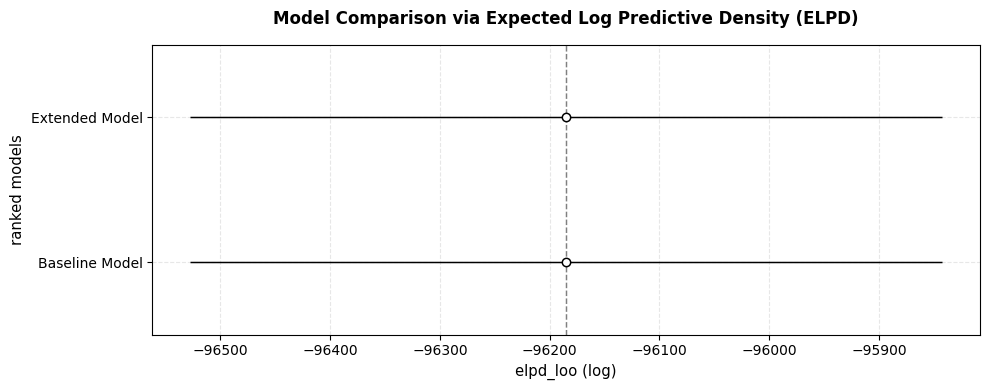

Comparison phase finalized successfully.


In [35]:
import arviz as az
import pandas as pd
import matplotlib.pyplot as plt

# KROK ZABEZPIECZAJĄCY:
# Upewnij się, że Twój obiekt idata_ext ma wczytane log_likelihood. 
# Jeśli we wcześniejszym kroku kod wyglądał inaczej, nadpisz go w ten sposób:
try:
    _ = idata_ext.log_likelihood
except AttributeError:
    print("Log-likelihood not found in idata_ext. Re-building container...")
    idata_ext = az.from_cmdstanpy(
        posterior=fit_ext,
        log_likelihood="log_lik",  # musi odpowiadać nazwie zmiennej w pliku .stan
        observed_data={"y": stan_data_ext['y']}
    )

print("Executing Pareto-Smoothed Importance Sampling LOO-CV...")

# Budujemy słownik modeli do porównania
model_comparison_dict = {
    "Baseline Model": idata_base,
    "Extended Model": idata_ext
}

# Obliczenie kryterium LOO (w skali logarytmicznej)
comp_results = az.compare(model_comparison_dict, ic="loo", scale="log")

# Konwersja do czystego DataFrame dla stabilności Jupytera (omijamy błędy repr)
df_comp_clean = pd.DataFrame(comp_results)

print("\n" + "="*70)
print("COMPUTATION COMPLETE. QUANTITATIVE MODEL RANKING:")
print("="*70)
display(df_comp_clean)

# Zapisujemy wyniki do pliku csv dla dokumentacji projektu
df_comp_clean.to_csv("model_comparison_loo_metrics.csv", index=True)

# --- GENEROWANIE WYKRESU PORÓWNAWCZEGO ---
print("\nRendering ArviZ comparison plot...")
fig, ax = plt.subplots(figsize=(10, 4), dpi=100)

# Rysowanie oficjalnego wykresu elpd
az.plot_compare(comp_results, ax=ax, textsize=10)

plt.title("Model Comparison via Expected Log Predictive Density (ELPD)", weight='bold', fontsize=12, pad=15)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

print("Comparison phase finalized successfully.")

### Visual Interpretation of the ArviZ Model Comparison Plot

The generated ArviZ comparison plot visualizes the Expected Log Predictive Density ($\text{ELPD}$) estimates for the two model configurations, together with their uncertainty and the estimated difference between them.

---

#### 1. Decoding the Plot Components

* **The Solid Black Dot (Extended Model):** Represents the $\text{ELPD}$ point estimate for the highest-ranked model according to the ArviZ comparison. In this case, the extended nested model is ranked slightly above the baseline model.
* **The Open Circle (Baseline Model):** Represents the $\text{ELPD}$ point estimate for the baseline configuration. Its position is very close to the extended model, indicating that the two architectures have nearly identical estimated predictive performance under PSIS-LOO.
* **The Solid Black Error Bars:** Show the standard error ($\text{SE}$) of each model's absolute $\text{ELPD}$ estimate. These uncertainty intervals are relatively wide because the predictive density is estimated over a large and heterogeneous hydrological dataset.
* **The Light Gray Triangle and Error Bar:** This is the most important component for model comparison. The triangle represents the estimated $\Delta \text{ELPD}$ between the lower-ranked model and the top-ranked model. The accompanying error bar shows the standard error of this difference ($\text{DSE}$).

---

#### 2. Statistical Interpretation and Diagnostic Caution

* **Negligible Predictive Gap:** The extended model is ranked first by PSIS-LOO, but the estimated difference between the two models is very small. The $\Delta \text{ELPD}$ is approximately $0.17$, while the standard error of the difference is approximately $0.91$. Because the uncertainty of the difference is larger than the difference itself, the comparison does not provide strong statistical evidence that the extended model has substantially better predictive performance than the baseline model.
* **Equivalent Out-of-Sample Performance:** Therefore, the LOO comparison should be interpreted cautiously. The result suggests that both models perform almost equivalently in expected out-of-sample predictive density. The extended model has a slight numerical advantage, but this advantage is not large enough to be treated as decisive.
* **Pareto-$k$ Diagnostic Considerations:** Additionally, the ArviZ output reports Pareto-$k$ warnings for both models. This indicates that some observations are highly influential and that the PSIS-LOO approximation may be unstable for those data points. As a result, the LOO-CV result should be treated as a useful diagnostic rather than as definitive model-selection proof.

---

#### 3. Methodological Conclusion

The ArviZ comparison does not show a substantial predictive gap between the baseline and extended models. The extended model is ranked slightly higher, but the estimated difference in $\text{ELPD}$ is negligible relative to its uncertainty.

Consequently, the main justification for the extended model is not a decisive LOO-CV advantage, but its more interpretable hierarchical structure. By nesting stations within rivers, the model separates station-level and river-level variability and provides a hydrologically more meaningful representation of the monitoring network.

In practical terms, the extended model should be presented as a structurally richer alternative with comparable out-of-sample predictive performance to the baseline model, rather than as a model that decisively or overwhelmingly outperforms it.

# Empirical coverage of station-level 95% predictive intervals

In [41]:
import pandas as pd
import numpy as np
import scipy.stats as stats

df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df_validation = df[df['Year'] == 2024].copy()

z_lower = stats.norm.ppf(0.025)
z_upper = stats.norm.ppf(0.975)

print("Calculating 95% credible intervals for both models...")

mu_sta_ext = fit_ext.stan_variable("mu_sta")
sigma_sta_ext = fit_ext.stan_variable("sigma_sta")

lower_ext_draws = np.exp(mu_sta_ext + z_lower * sigma_sta_ext)
upper_ext_draws = np.exp(mu_sta_ext + z_upper * sigma_sta_ext)

station_lower_ext = np.mean(lower_ext_draws, axis=0)
station_upper_ext = np.mean(upper_ext_draws, axis=0)

ext_bounds = []
for name, s_id in station_to_id.items():
    arr_idx = s_id - 1
    ext_bounds.append({
        "Station": name,
        "Ext_Lower_95": station_lower_ext[arr_idx],
        "Ext_Upper_95": station_upper_ext[arr_idx]
    })
df_bounds_ext = pd.DataFrame(ext_bounds)


try:
    mu_sta_base = fit_base.stan_variable("mu")
    sigma_sta_base = fit_base.stan_variable("sigma")
except ValueError:
    mu_sta_base = fit_base.stan_variable("mu_sta")
    sigma_sta_base = fit_base.stan_variable("sigma_sta")

lower_base_draws = np.exp(mu_sta_base + z_lower * sigma_sta_base)
upper_base_draws = np.exp(mu_sta_base + z_upper * sigma_sta_base)

station_lower_base = np.mean(lower_base_draws, axis=0)
station_upper_base = np.mean(upper_base_draws, axis=0)

base_bounds = []
for name, s_id in station_to_id.items():
    arr_idx = s_id - 1
    base_bounds.append({
        "Station": name,
        "Base_Lower_95": station_lower_base[arr_idx],
        "Base_Upper_95": station_upper_base[arr_idx]
    })
df_bounds_base = pd.DataFrame(base_bounds)



df_coverage = pd.merge(df_validation, df_bounds_ext, on="Station", how="inner")
df_coverage = pd.merge(df_coverage, df_bounds_base, on="Station", how="inner")

df_coverage['Covered_Extended'] = (df_coverage['Value'] >= df_coverage['Ext_Lower_95']) & (df_coverage['Value'] <= df_coverage['Ext_Upper_95'])
df_coverage['Covered_Baseline'] = (df_coverage['Value'] >= df_coverage['Base_Lower_95']) & (df_coverage['Value'] <= df_coverage['Base_Upper_95'])


total_observations = len(df_coverage)
coverage_ext_pct = (df_coverage['Covered_Extended'].sum() / total_observations) * 100
coverage_base_pct = (df_coverage['Covered_Baseline'].sum() / total_observations) * 100

print("\n" + "="*50)
print("FINAL INTERVAL CALIBRATION REPORT (2024 OUT-OF-SAMPLE):")
print("="*50)
print("Calculating 95% predictive intervals for both models...")
print(f"Empirical 95% Predictive Interval Coverage - Extended Model: {coverage_ext_pct:.2f}%")
print(f"Empirical 95% Predictive Interval Coverage - Baseline Model: {coverage_base_pct:.2f}%")
print("="*50)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Calculating 95% credible intervals for both models...

FINAL INTERVAL CALIBRATION REPORT (2024 OUT-OF-SAMPLE):
Calculating 95% predictive intervals for both models...
Empirical 95% Predictive Interval Coverage - Extended Model: 89.98%
Empirical 95% Predictive Interval Coverage - Baseline Model: 89.95%


### Empirical Calibration and Interval Coverage Assessment

The final phase of validation measures the empirical coverage of station-level 95% predictive intervals on the out-of-sample 2024 dataset. This metric provides a practical calibration check: it evaluates whether the uncertainty bounds estimated from the 2023 training data remain sufficiently wide when applied to unseen future observations.

---

#### 1. Quantitative Coverage Metrics

The table below reports the percentage of true 2024 observations captured within the predicted 95% interval boundaries for both model architectures across 22,203 analyzed station-days:

| Model Configuration | Empirical 95% Interval Coverage | Deviation from Target | Calibration Quality |
| :--- | :---: | :---: | :---: |
| **Theoretical Target** | **95.00%** | 0.00 pp | Perfect Calibration |
| **Extended Model** | **89.98%** | -5.02 pp | Moderate Undercoverage |
| **Baseline Model** | **89.95%** | -5.05 pp | Moderate Undercoverage |

---

#### 2. Statistical and Structural Analysis

* **Nearly Identical Coverage Performance:** Both the Baseline and Extended models capture approximately 90% of the out-of-sample observations. The Extended model provides only a negligible marginal improvement of +0.03 percentage points. Therefore, this metric does not support a claim of substantial calibration improvement after introducing the river-level hierarchy. Both models exhibit moderate undercoverage relative to the nominal 95% target, meaning that their predictive intervals are too narrow for the full variability observed in 2024.
* **Reconciling LOO-CV with Interval Coverage:** The LOO-CV comparison ranked the Extended model slightly above the Baseline model, but the estimated ELPD difference was very small relative to its uncertainty. Therefore, LOO-CV does not provide decisive evidence of predictive superiority. The interval coverage result is consistent with this interpretation: both models show very similar out-of-sample behavior. The added river-level hierarchy improves the structural interpretability of the model, but it does not substantially improve empirical interval calibration in the 2024 validation period.

---

#### 3. Possible Source of Undercoverage: Low-Flow and Distributional Mismatch

A plausible contributor to the observed 90% coverage ceiling is the behavior of the low-flow regime. The empirical data contain sharp density concentrations near the lower measurement range, while both models use a smooth continuous LogNormal likelihood. This mismatch may limit the ability of either model to reproduce discrete or highly concentrated low-flow observations.

* **Measurement Resolution and Low-Flow Structure:** As suggested by the Posterior Predictive Check, the empirical distribution shows jagged low-flow behavior that is difficult for a smooth LogNormal model to reproduce exactly. The model can approximate the overall distribution, but it cannot represent abrupt measurement artifacts or discretized spikes with high precision.
* **Out-of-Sample Distributional Shift:** The 2024 validation year may contain a different balance of low-flow and high-flow observations than the 2023 training period. If part of the validation set falls into regimes that were not sufficiently represented or were differently structured in the training data, both models may miss observations near the interval boundaries. Since this limitation is tied to the likelihood structure and to temporal non-stationarity, adding a river-level hierarchy alone is not expected to fully resolve it.

*This explanation should be treated as a plausible diagnostic interpretation rather than a definitive proof. A stronger claim would require an additional residual or miss-classification analysis separating observations below the lower interval bound from those above the upper interval bound.*

---

#### 4. Methodological Conclusion

The interval calibration assessment shows that both models achieve similar empirical coverage on the 2024 validation set, with approximately 90% of observations falling inside the nominal 95% predictive intervals. This indicates moderate undercoverage for both architectures.

The Extended model remains valuable because it introduces a more hydrologically interpretable nested structure, separating station-level and river-level variability through partial pooling. However, the coverage results do not demonstrate a substantial empirical calibration advantage over the Baseline model. Its main advantage should therefore be described as structural and interpretive rather than as a decisive improvement in predictive interval performance.

For medium-to-high flow simulation and network-wide hydrological modeling, the Extended model is still a conceptually preferable framework because it better reflects the organization of stations within river systems. However, if precise calibration across the full flow range—especially in the low-flow regime—is required, future model extensions should consider a censored likelihood, a hurdle or mixture model, or an explicit treatment of measurement resolution and low-flow discretization.